# Target-Directed EDA: Revenue & COGS Daily Analysis

Notebook này tập trung giải quyết bài toán trọng tâm: **Xác định các động lực (drivers) gây biến động Revenue/COGS theo ngày** và sàng lọc tín hiệu cho giai đoạn Feature Engineering.

### Key Objectives
- Kiểm chứng **05 Giả thuyết (H1-H5)** về biến động kinh doanh.
- Kiểm soát **tính toàn vẹn của dữ liệu** (Grain, Coverage, Join Risk).
- Xây dựng danh mục **Feature Candidates** dựa trên bằng chứng thực nghiệm.

## Phase 0: Environment Setup & Utilities

In [82]:
from pathlib import Path
import sys
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "data").exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))
import ds_utils as du

du.setup_notebook(max_columns=120, max_rows=120, figsize=(11, 5))

REPORT_DIR = PROJECT_ROOT / "report_4_6_2026"
OUTPUT_DIR = REPORT_DIR / "eda_outputs"
TABLE_DIR = OUTPUT_DIR / "tables"
FIG_DIR = OUTPUT_DIR / "figures"
for path in [OUTPUT_DIR, TABLE_DIR, FIG_DIR]:
    path.mkdir(parents=True, exist_ok=True)

DATA_DIR = PROJECT_ROOT / "data"
TARGETS = ["Revenue", "COGS"]

def save_df(df, name):
    path = TABLE_DIR / name
    df.to_csv(path, index=False, encoding="utf-8-sig")
    print(f"saved: {path.relative_to(PROJECT_ROOT)}")
    return path

def save_fig(name):
    path = FIG_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    print(f"saved: {path.relative_to(PROJECT_ROOT)}")
    plt.show()
    return path

def check_join_row_count(left, joined, name):
    return {
        "check": name,
        "left_rows": len(left),
        "joined_rows": len(joined),
        "row_count_changed": len(left) != len(joined),
        "status": "PASS" if len(left) == len(joined) else "REVIEW",
    }

def safe_corr(df, features, targets=TARGETS):
    use_features = [f for f in features if f in df.columns]
    return du.target_relation_report(df, use_features, targets, min_pairs=30) if use_features else pd.DataFrame()


## Phase A: Chọn target và scope

### 0. Load dữ liệu trong scope

**Mục tiêu**: Load các bảng dữ liệu cần thiết từ thư mục data để chuẩn bị cho quá trình scoping và phân tích.

#### Quy trình

- Đọc các file dữ liệu trong scope từ thư mục data.
- Chuẩn hóa tên bảng thành các DataFrame dễ gọi như sales, orders, web_traffic.
- Kiểm tra load status, số dòng và số cột của từng bảng.
- Xác nhận sales và sample_submission tồn tại trước khi chọn target.
- Ghi output load_scope_check để làm bằng chứng cho Phase A.

In [83]:
files = {
    "sales": "sales.csv",
    "sample_submission": "sample_submission.csv",
    "web_traffic": "web_traffic.csv",
    "orders": "orders.csv",
    "order_items": "order_items.csv",
    "promotions": "promotions.csv",
    "inventory": "inventory.csv",
    "products": "products.csv",
}

tables = {}
for name, file_name in files.items():
    path = DATA_DIR / file_name
    if path.exists():
        tables[name] = du.read_csv(path)
        print(f"{name}: {tables[name].shape}")
    else:
        print(f"MISSING: {name} -> {file_name}")

sales = tables["sales"].copy()
sample_submission = tables["sample_submission"].copy()
sales["Date"] = pd.to_datetime(sales["Date"], errors="coerce").dt.normalize()
sample_submission["Date"] = pd.to_datetime(sample_submission["Date"], errors="coerce").dt.normalize()
for col in TARGETS:
    sales[col] = pd.to_numeric(sales[col], errors="coerce")


sales: (3833, 3)
sample_submission: (548, 3)
web_traffic: (3652, 7)
orders: (646945, 8)
order_items: (714669, 7)
promotions: (50, 10)
inventory: (60247, 17)
products: (2412, 8)


### 1. Chọn target

**Mục tiêu**: Xác định target chính của bài toán và kiểm tra bằng dữ liệu thật rằng target đó tồn tại trong cả bảng train và forecast frame.

#### Quy trình

- Kiểm tra Revenue và COGS có trong sales.
- Kiểm tra Revenue và COGS có trong sample_submission.
- Kiểm tra sales.Date unique ở grain ngày.
- Kiểm tra target có thể chuyển sang numeric.
- Ghi analysis_story_scope để khóa câu chuyện phân tích chính.

In [84]:
sales_target_cols_ok = all(c in sales.columns for c in TARGETS)
submission_target_cols_ok = all(c in sample_submission.columns for c in TARGETS)
sales_date_unique = sales["Date"].notna().all() and sales["Date"].is_unique
sales_daily_continuous = pd.date_range(sales["Date"].min(), sales["Date"].max(), freq="D").size == sales["Date"].nunique()
target_numeric_parseable = all(pd.to_numeric(tables["sales"][c], errors="coerce").notna().all() for c in TARGETS)

target_selection_check = pd.DataFrame([
    {"check_name": "target_columns_in_sales", "result": ", ".join(TARGETS), "evidence": f"sales columns include {TARGETS}", "status": "PASS" if sales_target_cols_ok else "REVIEW"},
    {"check_name": "target_columns_in_sample_submission", "result": ", ".join(TARGETS), "evidence": f"sample_submission columns include {TARGETS}", "status": "PASS" if submission_target_cols_ok else "REVIEW"},
    {"check_name": "sales_date_unique", "result": sales_date_unique, "evidence": f"sales rows={len(sales)}, unique Date={sales['Date'].nunique()}", "status": "PASS" if sales_date_unique else "REVIEW"},
    {"check_name": "sales_daily_continuous", "result": sales_daily_continuous, "evidence": f"sales period={sales['Date'].min().date()} to {sales['Date'].max().date()}", "status": "PASS" if sales_daily_continuous else "REVIEW"},
    {"check_name": "target_numeric_parseable", "result": target_numeric_parseable, "evidence": "Revenue/COGS converted to numeric without null after parse", "status": "PASS" if target_numeric_parseable else "REVIEW"},
])
save_df(target_selection_check, "target_selection_check.csv")
du.show(target_selection_check[["check_name", "result", "status"]], title="A.1 Target selection check")

analysis_story_scope = pd.DataFrame([
    {"item": "main_story", "value": "Vì sao Revenue và COGS biến động theo ngày?", "evidence": "bám đúng target cần dự đoán", "status": "PASS"},
    {"item": "target_table", "value": "sales", "evidence": "sales có Date, Revenue, COGS", "status": "PASS" if sales_target_cols_ok else "REVIEW"},
    {"item": "target_columns", "value": ", ".join(TARGETS), "evidence": "trùng sample_submission", "status": "PASS" if submission_target_cols_ok else "REVIEW"},
    {"item": "next_pipeline_step", "value": "feature engineering", "evidence": "EDA chỉ đề xuất feature candidate, chưa chốt feature cuối cùng", "status": "PASS"},
])
save_df(analysis_story_scope, "analysis_story_scope.csv")
du.show(analysis_story_scope[["item", "value", "status"]], title="A.1 Analysis story scope")


saved: report_4_6_2026/eda_outputs/tables/target_selection_check.csv

A.1 Target selection check


,check_name,result,status
0,target_columns_in_sales,"Revenue, COGS",PASS
1,target_columns_in_sample_submission,"Revenue, COGS",PASS
2,sales_date_unique,True,PASS
3,sales_daily_continuous,True,PASS
4,target_numeric_parseable,True,PASS


saved: report_4_6_2026/eda_outputs/tables/analysis_story_scope.csv

A.1 Analysis story scope


,item,value,status
0,main_story,Vì sao Revenue và COGS biến động theo ngày?,PASS
1,target_table,sales,PASS
2,target_columns,"Revenue, COGS",PASS
3,next_pipeline_step,feature engineering,PASS


### 2. Chọn forecast grain và forecast frame

**Mục tiêu**: Xác định mỗi dòng cần dự đoán đại diện cho cái gì và kiểm tra forecast frame có đúng grain ngày không.

#### Quy trình

- Xác định sample_submission là forecast frame.
- Kiểm tra mỗi dòng forecast đại diện cho 1 ngày.
- Kiểm tra Date trong sample_submission unique và daily continuous.
- Kiểm tra forecast period bắt đầu sau train period của sales.
- Ghi rõ notebook đang dừng ở EDA, chưa sang modeling.

In [85]:
submission_date_unique = sample_submission["Date"].notna().all() and sample_submission["Date"].is_unique
submission_daily_continuous = pd.date_range(sample_submission["Date"].min(), sample_submission["Date"].max(), freq="D").size == sample_submission["Date"].nunique()
forecast_starts_after_train = sample_submission["Date"].min() > sales["Date"].max()
forecast_columns_ok = all(c in sample_submission.columns for c in ["Date", *TARGETS])

forecast_scope_check = pd.DataFrame([
    {"check_name": "forecast_frame", "result": "sample_submission", "evidence": f"columns include Date and {TARGETS}", "status": "PASS" if forecast_columns_ok else "REVIEW"},
    {"check_name": "forecast_grain", "result": "daily", "evidence": f"rows={len(sample_submission)}, unique Date={sample_submission['Date'].nunique()}", "status": "PASS" if submission_date_unique and submission_daily_continuous else "REVIEW"},
    {"check_name": "train_period", "result": f"{sales['Date'].min().date()} to {sales['Date'].max().date()}", "evidence": "from sales.Date", "status": "PASS"},
    {"check_name": "forecast_period", "result": f"{sample_submission['Date'].min().date()} to {sample_submission['Date'].max().date()}", "evidence": "from sample_submission.Date", "status": "PASS"},
    {"check_name": "train_forecast_order", "result": "forecast starts after train ends", "evidence": f"forecast_start={sample_submission['Date'].min().date()}, train_end={sales['Date'].max().date()}", "status": "PASS" if forecast_starts_after_train else "REVIEW"},
    {"check_name": "notebook_stage", "result": "EDA only", "evidence": "chưa clean mạnh, chưa train model, chưa chốt feature cuối cùng", "status": "PASS"},
])
save_df(forecast_scope_check, "forecast_scope_check.csv")
du.show(forecast_scope_check[["check_name", "result", "status"]], title="A.2 Forecast scope check")


saved: report_4_6_2026/eda_outputs/tables/forecast_scope_check.csv

A.2 Forecast scope check


,check_name,result,status
0,forecast_frame,sample_submission,PASS
1,forecast_grain,daily,PASS
2,train_period,2012-07-04 to 2022-12-31,PASS
3,forecast_period,2023-01-01 to 2024-07-01,PASS
4,train_forecast_order,forecast starts after train ends,PASS
5,notebook_stage,EDA only,PASS


### 3. Chọn các bảng liên quan đến target

**Mục tiêu**: Chọn các bảng có khả năng giải thích biến động daily Revenue/COGS, đồng thời ghi rõ grain, vai trò phân tích và rủi ro trước khi EDA.

#### Quy trình

- 3.1 Hypothesis backlog: lập H1-H5 gắn target với bảng nguồn.
- 3.2 Helper và rule kiểm tra feasibility: định nghĩa rule về bảng/cột, grain, coverage, join risk và leakage.
- 3.3 Feasibility check H1-H5: kiểm tra giả thuyết nào đủ dữ liệu để EDA.
- 3.4 Chốt bảng phân tích: quyết định bảng keep, skip hoặc insight-only.
- 3.5 Audit câu hỏi phần A: xác nhận Phase A có đủ bằng chứng trước khi sang EDA.

#### 3.1 Hypothesis backlog

**Mục tiêu**: Biến câu chuyện daily Revenue/COGS thành các giả thuyết H1-H5 có thể kiểm chứng bằng dữ liệu thật.

#### Quy trình

- Ghi mỗi giả thuyết thành một dòng trong hypothesis_backlog.
- Gắn hypothesis với target metric cần giải thích.
- Gắn hypothesis với bảng nguồn và grain gốc.
- Ghi expected pattern trước khi xem kết quả để tránh diễn giải tùy tiện.
- Ghi join risk và leakage risk ngay từ backlog.

In [86]:
hypothesis_backlog = pd.DataFrame([
    {
        "hypothesis_id": "H1",
        "hypothesis": "Revenue và COGS có trend, seasonality, outlier theo ngày/tháng/năm",
        "target_metric": "Revenue, COGS",
        "source_tables": "sales",
        "original_grain": "daily",
        "analysis_grain": "daily/monthly",
        "expected_pattern": "trend/weekly/monthly seasonality/outlier",
        "join_risk": "none",
        "leakage_risk": "low",
        "priority": "high",
    },
    {
        "hypothesis_id": "H2",
        "hypothesis": "Web traffic tăng trước hoặc gần ngày bán thì Revenue/COGS tăng",
        "target_metric": "Revenue, COGS",
        "source_tables": "web_traffic, sales",
        "original_grain": "date or date x traffic_source",
        "analysis_grain": "daily",
        "expected_pattern": "traffic lag/rolling tương quan dương với target",
        "join_risk": "medium nếu chưa aggregate về ngày",
        "leakage_risk": "medium với same-day, thấp hơn với lag/rolling",
        "priority": "high",
    },
    {
        "hypothesis_id": "H3",
        "hypothesis": "Order volume là driver lớn của Revenue",
        "target_metric": "Revenue",
        "source_tables": "orders, sales",
        "original_grain": "order",
        "analysis_grain": "daily",
        "expected_pattern": "order_count tăng thì Revenue tăng",
        "join_risk": "medium nếu join raw orders vào sales",
        "leakage_risk": "high với same-day order_count nếu forecast trước ngày",
        "priority": "high",
    },
    {
        "hypothesis_id": "H4",
        "hypothesis": "Promotion/discount làm Revenue tăng nhưng margin có thể giảm",
        "target_metric": "Revenue, Gross_Margin",
        "source_tables": "promotions, order_items, sales",
        "original_grain": "promotion calendar + item",
        "analysis_grain": "daily",
        "expected_pattern": "promo active ngày nào có Revenue/margin khác ngày thường",
        "join_risk": "medium nếu calendar/item usage chưa aggregate",
        "leakage_risk": "low với calendar, medium/high với item usage same-day",
        "priority": "medium",
    },
    {
        "hypothesis_id": "H5",
        "hypothesis": "Inventory stockout/fill rate có thể làm Revenue thấp",
        "target_metric": "Revenue",
        "source_tables": "inventory, sales",
        "original_grain": "inventory snapshot",
        "analysis_grain": "daily/monthly tùy coverage",
        "expected_pattern": "stockout cao/fill rate thấp đi cùng Revenue thấp",
        "join_risk": "medium nếu snapshot không cùng grain target",
        "leakage_risk": "medium tùy thời điểm snapshot",
        "priority": "medium",
    },
])
save_df(hypothesis_backlog, "hypothesis_backlog.csv")
hypothesis_backlog.to_csv(OUTPUT_DIR / "hypothesis_backlog.csv", index=False, encoding="utf-8-sig")
du.show(hypothesis_backlog, title="Hypothesis backlog H1-H5")


saved: report_4_6_2026/eda_outputs/tables/hypothesis_backlog.csv

Hypothesis backlog H1-H5


,hypothesis_id,hypothesis,target_metric,source_tables,original_grain,analysis_grain,expected_pattern,join_risk,leakage_risk,priority
0,H1,"Revenue và COGS có trend, seasonality, outlier...","Revenue, COGS",sales,daily,daily/monthly,trend/weekly/monthly seasonality/outlier,none,low,high
1,H2,Web traffic tăng trước hoặc gần ngày bán thì R...,"Revenue, COGS","web_traffic, sales",date or date x traffic_source,daily,traffic lag/rolling tương quan dương với target,medium nếu chưa aggregate về ngày,"medium với same-day, thấp hơn với lag/rolling",high
2,H3,Order volume là driver lớn của Revenue,Revenue,"orders, sales",order,daily,order_count tăng thì Revenue tăng,medium nếu join raw orders vào sales,high với same-day order_count nếu forecast trư...,high
3,H4,Promotion/discount làm Revenue tăng nhưng marg...,"Revenue, Gross_Margin","promotions, order_items, sales",promotion calendar + item,daily,promo active ngày nào có Revenue/margin khác n...,medium nếu calendar/item usage chưa aggregate,"low với calendar, medium/high với item usage s...",medium
4,H5,Inventory stockout/fill rate có thể làm Revenu...,Revenue,"inventory, sales",inventory snapshot,daily/monthly tùy coverage,stockout cao/fill rate thấp đi cùng Revenue thấp,medium nếu snapshot không cùng grain target,medium tùy thời điểm snapshot,medium


#### 3.2 Helper và rule kiểm tra feasibility

**Mục tiêu**: Tạo helper/rule để kiểm tra giả thuyết có đủ bảng, đủ cột, đúng grain và đủ coverage trước khi EDA.

#### Quy trình

- Định nghĩa helper kiểm tra bảng có tồn tại trong scope.
- Định nghĩa helper kiểm tra cột bắt buộc theo từng hypothesis.
- Định nghĩa rule kiểm tra grain có đưa về daily hoặc monthly được không.
- Định nghĩa rule kiểm tra coverage overlap với sales.Date.
- Định nghĩa flag join risk và leakage risk trước khi phân tích sâu.

In [87]:
def date_coverage(df, date_col):
    if date_col not in df.columns:
        return {"min_date": pd.NaT, "max_date": pd.NaT, "unique_dates": 0, "missing_dates": np.nan, "coverage_ratio_vs_sales": 0.0}
    s = pd.to_datetime(df[date_col], errors="coerce").dt.normalize()
    if s.dropna().empty:
        return {"min_date": pd.NaT, "max_date": pd.NaT, "unique_dates": 0, "missing_dates": np.nan, "coverage_ratio_vs_sales": 0.0}
    unique_dates = pd.Index(s.dropna().unique())
    full = pd.date_range(s.min(), s.max(), freq="D")
    sales_dates = pd.Index(sales["Date"].dropna().unique())
    overlap_days = len(sales_dates.intersection(unique_dates))
    return {
        "min_date": s.min(),
        "max_date": s.max(),
        "unique_dates": int(s.nunique()),
        "missing_dates": int(len(full.difference(unique_dates))),
        "overlap_days_vs_sales": int(overlap_days),
        "coverage_ratio_vs_sales": round(overlap_days / max(1, len(sales_dates)), 4),
    }

def coverage_decision(hid, cov):
    ratio = cov.get("coverage_ratio_vs_sales", 0)
    unique_dates = cov.get("unique_dates", 0)
    if hid == "H1":
        return "PASS" if unique_dates == sales["Date"].nunique() else "REVIEW"
    if hid == "H2":
        return "PARTIAL" if ratio < 0.98 else "PASS"
    if hid == "H3":
        return "PASS" if ratio >= 0.98 else "PARTIAL"
    if hid == "H4":
        return "PASS_CALENDAR_EDA"
    if hid == "H5":
        return "PARTIAL_NOT_DAILY" if unique_dates < sales["Date"].nunique() else "PASS"
    return "REVIEW"

requirements = {
    "H1": {"tables": ["sales"], "columns": {"sales": ["Date", "Revenue", "COGS"]}, "date_table": "sales", "date_col": "Date"},
    "H2": {"tables": ["web_traffic", "sales"], "columns": {"web_traffic": ["date", "sessions"], "sales": ["Date", "Revenue", "COGS"]}, "date_table": "web_traffic", "date_col": "date"},
    "H3": {"tables": ["orders", "sales"], "columns": {"orders": ["order_date", "order_id"], "sales": ["Date", "Revenue"]}, "date_table": "orders", "date_col": "order_date"},
    "H4": {"tables": ["promotions", "sales"], "columns": {"promotions": ["start_date", "end_date"], "sales": ["Date", "Revenue", "COGS"]}, "date_table": "promotions", "date_col": "start_date"},
    "H5": {"tables": ["inventory", "sales"], "columns": {"inventory": ["snapshot_date"], "sales": ["Date", "Revenue"]}, "date_table": "inventory", "date_col": "snapshot_date"},
}


#### 3.3 Feasibility check H1-H5

**Mục tiêu**: Chạy rule feasibility cho từng giả thuyết để quyết định giả thuyết nào được phân tích sâu, giả thuyết nào chỉ ghi nhận rủi ro.

#### Quy trình

- Kiểm tra H1 với sales.
- Kiểm tra H2 với web_traffic và sales.
- Kiểm tra H3 với orders và sales.
- Kiểm tra H4 với promotions, order_items và sales.
- Kiểm tra H5 với inventory và sales.

In [88]:
feasibility_rows = []
for hid, req in requirements.items():
    missing_tables = [t for t in req["tables"] if t not in tables]
    missing_cols = []
    for t, cols in req["columns"].items():
        if t in tables:
            missing_cols += [f"{t}.{c}" for c in cols if c not in tables[t].columns]
    cov = date_coverage(tables[req["date_table"]], req["date_col"]) if req["date_table"] in tables else {}
    data_available = not missing_tables and not missing_cols
    coverage_status = coverage_decision(hid, cov) if data_available else "REVIEW"
    coverage_feasible = coverage_status in {"PASS", "PASS_CALENDAR_EDA"}

    if hid == "H1":
        grain_feasible = "already_daily"
        decision = "keep_for_eda" if data_available and coverage_feasible else "review_before_eda"
    elif hid == "H5":
        grain_feasible = "snapshot_not_daily"
        decision = "eda_insight_only_not_daily_feature"
    elif hid == "H4":
        grain_feasible = "promotion_calendar_to_daily"
        decision = "need_daily_aggregation"
    else:
        grain_feasible = "needs_daily_aggregation"
        decision = "need_daily_aggregation" if data_available else "skip_for_now"

    feasibility_rows.append({
        "hypothesis_id": hid,
        "required_tables": ", ".join(req["tables"]),
        "required_columns": json.dumps(req["columns"], ensure_ascii=False),
        "data_available": data_available,
        "grain_feasible": grain_feasible,
        "coverage_status": coverage_status,
        "coverage_feasible": coverage_feasible,
        "coverage_note": {
            "H1": "sales is daily and continuous",
            "H2": "web_traffic starts after sales start, so early sales dates have no traffic coverage",
            "H3": "orders cover the sales period and must be aggregated to daily before joining",
            "H4": "promotion table is a campaign calendar; not every sales day needs an active promo",
            "H5": "inventory has sparse snapshot coverage, not daily coverage",
        }[hid],
        "source_min_date": cov.get("min_date"),
        "source_max_date": cov.get("max_date"),
        "source_unique_dates": cov.get("unique_dates"),
        "overlap_days_vs_sales": cov.get("overlap_days_vs_sales"),
        "coverage_ratio_vs_sales": cov.get("coverage_ratio_vs_sales"),
        "join_risk": hypothesis_backlog.loc[hypothesis_backlog.hypothesis_id.eq(hid), "join_risk"].iloc[0],
        "leakage_risk": hypothesis_backlog.loc[hypothesis_backlog.hypothesis_id.eq(hid), "leakage_risk"].iloc[0],
        "decision": decision,
        "missing_tables": ", ".join(missing_tables),
        "missing_columns": ", ".join(missing_cols),
    })

hypothesis_feasibility_check = pd.DataFrame(feasibility_rows)
save_df(hypothesis_feasibility_check, "hypothesis_feasibility_check.csv")
hypothesis_feasibility_check.to_csv(OUTPUT_DIR / "hypothesis_feasibility_check.csv", index=False, encoding="utf-8-sig")
du.show(
    hypothesis_feasibility_check[["hypothesis_id", "grain_feasible", "coverage_status", "coverage_feasible", "decision"]],
    title="A.3 Feasibility decision summary",
)


saved: report_4_6_2026/eda_outputs/tables/hypothesis_feasibility_check.csv

A.3 Feasibility decision summary


,hypothesis_id,grain_feasible,coverage_status,coverage_feasible,decision
0,H1,already_daily,PASS,True,keep_for_eda
1,H2,needs_daily_aggregation,PARTIAL,False,need_daily_aggregation
2,H3,needs_daily_aggregation,PASS,True,need_daily_aggregation
3,H4,promotion_calendar_to_daily,PASS_CALENDAR_EDA,True,need_daily_aggregation
4,H5,snapshot_not_daily,PARTIAL_NOT_DAILY,False,eda_insight_only_not_daily_feature


#### 3.4 Chốt bảng phân tích

**Mục tiêu**: Chọn bảng dùng trong EDA dựa trên vai trò phân tích, grain cần đưa về và rủi ro ML.

#### Quy trình

- Chốt bảng target và forecast frame.
- Chốt bảng time-varying chính cho H1-H5.
- Chốt bảng hỗ trợ chỉ dùng để giải thích insight.
- Ghi required_grain cho từng bảng trước khi join hoặc aggregate.
- Ghi main_risk để bước EDA không vô tình tạo leakage.

In [89]:
selected_tables_for_eda = pd.DataFrame([
    {"table": "sales", "selected": True, "related_hypotheses": "H1-H5", "analysis_role": "target", "required_grain": "daily", "main_risk": "target outlier/margin issue"},
    {"table": "sample_submission", "selected": True, "related_hypotheses": "scope", "analysis_role": "forecast frame", "required_grain": "daily", "main_risk": "overlap/forecast gap"},
    {"table": "web_traffic", "selected": True, "related_hypotheses": "H2", "analysis_role": "traffic signal", "required_grain": "daily", "main_risk": "partial coverage and same-day leakage"},
    {"table": "orders", "selected": True, "related_hypotheses": "H3", "analysis_role": "order volume", "required_grain": "order -> daily", "main_risk": "same-day leakage"},
    {"table": "promotions", "selected": True, "related_hypotheses": "H4", "analysis_role": "planned promo calendar", "required_grain": "promotion -> daily", "main_risk": "calendar overlap/many active promos"},
    {"table": "order_items", "selected": "supporting", "related_hypotheses": "H4", "analysis_role": "promo usage insight", "required_grain": "item -> daily if used", "main_risk": "target proxy if using same-day revenue"},
    {"table": "inventory", "selected": "insight_only", "related_hypotheses": "H5", "analysis_role": "supply constraint context", "required_grain": "snapshot -> monthly/context", "main_risk": "not enough daily coverage"},
    {"table": "products", "selected": "supporting", "related_hypotheses": "insight only", "analysis_role": "lookup if needed", "required_grain": "product", "main_risk": "not a standalone driver"},
])
save_df(selected_tables_for_eda, "selected_tables_for_eda.csv")
du.show(selected_tables_for_eda[["table", "selected", "analysis_role", "required_grain", "main_risk"]], title="Selected tables for EDA")

eda_scope = pd.DataFrame([
    {"scope_area": "target", "decision": "Revenue, COGS", "reason": "trùng với sample_submission", "evidence": "target_selection_check status PASS", "main_risk": "target outlier/margin issue handled later in B.1", "status": "PASS"},
    {"scope_area": "forecast_grain", "decision": "daily", "reason": "mỗi dòng forecast là một ngày", "evidence": "forecast_scope_check status PASS", "main_risk": "none if Date remains unique", "status": "PASS"},
    {"scope_area": "primary_table", "decision": "sales", "reason": "chứa target chính", "evidence": f"sales rows={len(sales)}, unique Date={sales['Date'].nunique()}", "main_risk": "do not join raw one-to-many tables into sales", "status": "PASS"},
    {"scope_area": "selected_transaction_time_tables", "decision": "web_traffic, orders, promotions", "reason": "có tín hiệu thời gian hoặc giao dịch liên quan target", "evidence": "hypothesis_backlog + hypothesis_feasibility_check", "main_risk": "need aggregation/coverage/leakage review", "status": "PASS_WITH_REVIEW"},
    {"scope_area": "insight_only_tables", "decision": "inventory", "reason": "snapshot sparse, không đủ daily coverage", "evidence": "H5 coverage_status = PARTIAL_NOT_DAILY", "main_risk": "daily join can create sparse/biased feature", "status": "REVIEW"},
    {"scope_area": "supporting_tables", "decision": "order_items, products", "reason": "hỗ trợ promo usage/product lookup, không đứng thành hypothesis riêng", "evidence": "selected_tables_for_eda marks supporting", "main_risk": "target proxy if using same-day item revenue/discount", "status": "REVIEW"},
    {"scope_area": "out_of_scope", "decision": "redo check_quality, cleaning mạnh, feature cuối cùng, modeling", "reason": "thuộc bước khác", "evidence": "notebook_stage = EDA only", "main_risk": "scope creep", "status": "PASS"},
])
save_df(eda_scope, "eda_scope.csv")
du.show(eda_scope[["scope_area", "decision", "status", "main_risk"]], title="A.3 EDA scope decision")


saved: report_4_6_2026/eda_outputs/tables/selected_tables_for_eda.csv

Selected tables for EDA


,table,selected,analysis_role,required_grain,main_risk
0,sales,True,target,daily,target outlier/margin issue
1,sample_submission,True,forecast frame,daily,overlap/forecast gap
2,web_traffic,True,traffic signal,daily,partial coverage and same-day leakage
3,orders,True,order volume,order -> daily,same-day leakage
4,promotions,True,planned promo calendar,promotion -> daily,calendar overlap/many active promos
5,order_items,supporting,promo usage insight,item -> daily if used,target proxy if using same-day revenue
6,inventory,insight_only,supply constraint context,snapshot -> monthly/context,not enough daily coverage
7,products,supporting,lookup if needed,product,not a standalone driver


saved: report_4_6_2026/eda_outputs/tables/eda_scope.csv

A.3 EDA scope decision


,scope_area,decision,status,main_risk
0,target,"Revenue, COGS",PASS,target outlier/margin issue handled later in B.1
1,forecast_grain,daily,PASS,none if Date remains unique
2,primary_table,sales,PASS,do not join raw one-to-many tables into sales
3,selected_transaction_time_tables,"web_traffic, orders, promotions",PASS_WITH_REVIEW,need aggregation/coverage/leakage review
4,insight_only_tables,inventory,REVIEW,daily join can create sparse/biased feature
5,supporting_tables,"order_items, products",REVIEW,target proxy if using same-day item revenue/di...
6,out_of_scope,"redo check_quality, cleaning mạnh, feature cuố...",PASS,scope creep


#### 3.5 Audit câu hỏi phần A

**Mục tiêu**: Đóng Phase A bằng bảng audit để bảo đảm mọi quyết định scope đều có bằng chứng dữ liệu.

#### Quy trình

- Kiểm tra target đã có trong train và forecast frame.
- Kiểm tra forecast grain daily đã được xác nhận.
- Kiểm tra bảng phân tích đã gắn với H1-H5.
- Kiểm tra grain, join risk và leakage risk đã được ghi.
- Tạo a_scope_answer_check để không bước sang EDA khi scope còn mơ hồ.

In [90]:
a_scope_answer_check = pd.DataFrame([
    {"plan_step": "A.0 Chọn target", "question": "Target cần phân tích là gì?", "answer": "Revenue, COGS", "evidence_output": "target_selection_check.csv; analysis_story_scope.csv", "status": "PASS"},
    {"plan_step": "A.0 Chọn target", "question": "Target nằm ở bảng nào và có trùng sample_submission không?", "answer": "Target nằm ở sales và trùng cột Revenue/COGS trong sample_submission", "evidence_output": "target_selection_check.csv", "status": "PASS"},
    {"plan_step": "A.1 Chọn forecast", "question": "Mỗi dòng dự báo đại diện cho gì?", "answer": "1 dòng = 1 ngày", "evidence_output": "forecast_scope_check.csv", "status": "PASS"},
    {"plan_step": "A.1 Chọn forecast", "question": "Forecast period có nối tiếp train period không?", "answer": "Có, forecast bắt đầu ngay sau khi train kết thúc (2023-01-01)", "evidence_output": "forecast_scope_check.csv", "status": "PASS" if forecast_starts_after_train else "REVIEW"},
    {"plan_step": "A.2 Chọn bảng", "question": "Bảng nào liên quan trực tiếp đến target?", "answer": "sales, web_traffic, orders, promotions; inventory dùng làm context", "evidence_output": "eda_scope.csv; hypothesis_backlog.csv", "status": "PASS_WITH_REVIEW"},
    {"plan_step": "A.2 Chọn bảng", "question": "Bảng nào chỉ hỗ trợ/lookup?", "answer": "order_items, products", "evidence_output": "eda_scope.csv; selected_tables_for_eda.csv", "status": "PASS"},
    {"plan_step": "A.2 Chọn bảng", "question": "Bảng nào cần aggregate trước khi join sales?", "answer": "web_traffic, orders, promotions", "evidence_output": "hypothesis_feasibility_check.csv", "status": "PASS_WITH_REVIEW"},
    {"plan_step": "A.2 Chọn bảng", "question": "Bảng nào có leakage risk nếu dùng same-day?", "answer": "orders và order_items (realized signals)", "evidence_output": "hypothesis_backlog.csv; eda_scope.csv", "status": "PASS_WITH_REVIEW"},
])
save_df(a_scope_answer_check, "a_scope_answer_check.csv")
du.show(a_scope_answer_check[["plan_step", "question", "answer", "status"]], title="A.4 Audit câu hỏi phần A")

saved: report_4_6_2026/eda_outputs/tables/a_scope_answer_check.csv

A.4 Audit câu hỏi phần A


,plan_step,question,answer,status
0,A.0 Chọn target,Target cần phân tích là gì?,"Revenue, COGS",PASS
1,A.0 Chọn target,Target nằm ở bảng nào và có trùng sample_submi...,Target nằm ở sales và trùng cột Revenue/COGS t...,PASS
2,A.1 Chọn forecast,Mỗi dòng dự báo đại diện cho gì?,1 dòng = 1 ngày,PASS
3,A.1 Chọn forecast,Forecast period có nối tiếp train period không?,"Có, forecast bắt đầu ngay sau khi train kết th...",PASS
4,A.2 Chọn bảng,Bảng nào liên quan trực tiếp đến target?,"sales, web_traffic, orders, promotions; invent...",PASS_WITH_REVIEW
5,A.2 Chọn bảng,Bảng nào chỉ hỗ trợ/lookup?,"order_items, products",PASS
6,A.2 Chọn bảng,Bảng nào cần aggregate trước khi join sales?,"web_traffic, orders, promotions",PASS_WITH_REVIEW
7,A.2 Chọn bảng,Bảng nào có leakage risk nếu dùng same-day?,orders và order_items (realized signals),PASS_WITH_REVIEW


**KL phần A:** Target là `Revenue/COGS`, forecast grain là daily. Bảng dùng cho B.EDA gồm `sales`, `web_traffic`, `orders`, `promotions`; `inventory` chỉ dùng insight-only do snapshot sparse. Không join raw one-to-many tables vào `sales` daily.


## Phase B: EDA theo câu chuyện chính và giả thuyết

### 1. EDA target để kiểm chứng H1

**Mục tiêu**: Kiểm chứng giả thuyết: H1: Revenue và COGS có trend, seasonality, outlier theo ngày/tháng/năm.

#### Quy trình

- Xác nhận nhanh sales.Date và grain daily từ kết quả check_quality.
- Tạo Gross_Profit và Gross_Margin để phân tích margin cùng target.
- Kiểm tra Revenue = 0, COGS > Revenue và margin âm.
- Thống kê phân phối Revenue, COGS và margin.
- Vẽ daily trend, rolling 7/30 ngày, monthly summary và calendar pattern.

In [91]:
# Tạo metric target mới ở grain daily.
target = sales.sort_values("Date").copy()
target["Gross_Profit"] = target["Revenue"] - target["COGS"]
target["Gross_Margin"] = np.where(target["Revenue"].ne(0), target["Gross_Profit"] / target["Revenue"], np.nan)
target["day_of_week"] = target["Date"].dt.day_name()
target["month"] = target["Date"].dt.month
target["year"] = target["Date"].dt.year
target["year_month"] = target["Date"].dt.to_period("M").astype(str)


In [92]:
# Thống kê phân phối target và metric mới.
target_descriptive_stats = du.numeric_summary(target, ["Revenue", "COGS", "Gross_Profit", "Gross_Margin"])
save_df(target_descriptive_stats, "target_descriptive_stats.csv")
du.show(target_descriptive_stats, title="Target descriptive stats")


saved: report_4_6_2026/eda_outputs/tables/target_descriptive_stats.csv

Target descriptive stats


,column,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,missing_pct,skew
0,Revenue,3833.0,4.286584e+06,2.624840e+06,2.798139e+05,8.450788e+05,1.352929e+06,2.471089e+06,3.647304e+06,5.350877e+06,9.398760e+06,1.380199e+07,2.090527e+07,0.0,1.670004
1,COGS,3833.0,3.695134e+06,2.219789e+06,2.365763e+05,7.381388e+05,1.176975e+06,2.150580e+06,3.161113e+06,4.637294e+06,8.090776e+06,1.157411e+07,1.653586e+07,0.0,1.625134
2,Gross_Profit,3833.0,5.914495e+05,6.661960e+05,-2.567312e+06,-1.297737e+06,-8.767850e+04,2.292740e+05,5.445544e+05,8.760810e+05,1.706283e+06,2.698726e+06,4.369414e+06,0.0,0.235257
3,Gross_Margin,3833.0,1.253931e-01,1.273561e-01,-5.745797e-01,-4.116046e-01,-4.453691e-02,8.261275e-02,1.783005e-01,2.028874e-01,2.254379e-01,2.442338e-01,2.869155e-01,0.0,-2.531628


saved: report_4_6_2026/eda_outputs/figures/fig_02_target_distribution.png


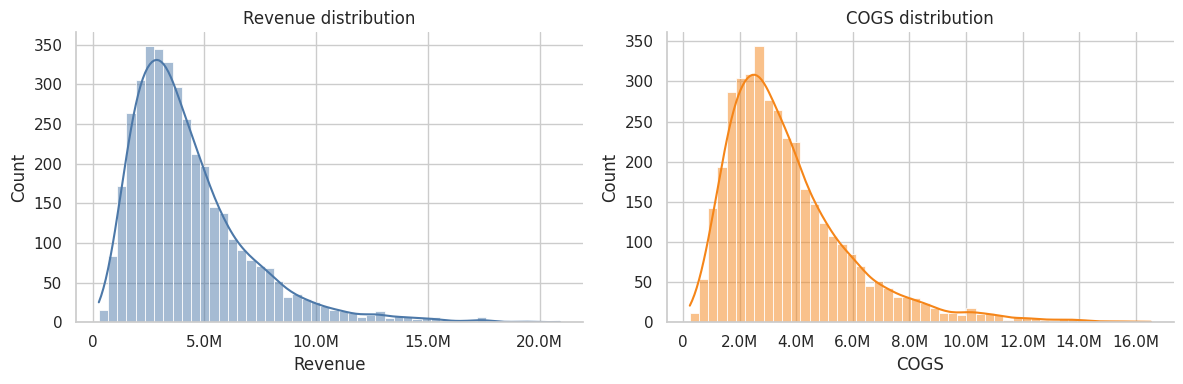

PosixPath('/content/report_4_6_2026/eda_outputs/figures/fig_02_target_distribution.png')

In [93]:
# Biểu đồ phân phối Revenue và COGS.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(target["Revenue"], bins=50, kde=True, ax=axes[0], color="#4c78a8")
axes[0].set_title("Revenue distribution")
axes[0].xaxis.set_major_formatter(du.MONEY_FORMATTER)
sns.histplot(target["COGS"], bins=50, kde=True, ax=axes[1], color="#f58518")
axes[1].set_title("COGS distribution")
axes[1].xaxis.set_major_formatter(du.MONEY_FORMATTER)
save_fig("fig_02_target_distribution.png")


In [94]:
# Phát hiện ngày bất thường: revenue quá thấp/quá cao, COGS > Revenue, margin âm.
q_low, q_high = target["Revenue"].quantile([0.01, 0.99])
target_outlier_days = target[
    (target["Revenue" ] <= q_low) |
    (target["Revenue"] >= q_high) |
    (target["COGS"] > target["Revenue"]) |
    (target["Gross_Margin"] < 0)
].copy()

target_outlier_days["outlier_reason"] = np.select(
    [
        target_outlier_days["Revenue"] <= q_low,
        target_outlier_days["Revenue"] >= q_high,
        target_outlier_days["COGS"] > target_outlier_days["Revenue"],
        target_outlier_days["Gross_Margin"] < 0,
    ],
    ["low_revenue_p01", "high_revenue_p99", "cogs_gt_revenue", "negative_margin"],
    default="review",
)

# Thống kê bảng tỷ lệ các sự kiện bất thường
outlier_summary = target_outlier_days["outlier_reason"].value_counts().reset_index()
outlier_summary.columns = ["outlier_reason", "day_count"]
outlier_summary["pct_of_total_days"] = (outlier_summary["day_count"] / len(target))

save_df(target_outlier_days, "target_outlier_days.csv")
save_df(outlier_summary, "target_outlier_summary_pct.csv")

du.show(outlier_summary, title="Tỷ lệ các sự kiện bất thường (trên tổng số ngày)")
du.show(target_outlier_days[["Date", "Revenue", "COGS", "Gross_Profit", "Gross_Margin", "outlier_reason"]].head(10), title="Chi tiết các ngày bất thường (Top 10)")

saved: report_4_6_2026/eda_outputs/tables/target_outlier_days.csv
saved: report_4_6_2026/eda_outputs/tables/target_outlier_summary_pct.csv

Tỷ lệ các sự kiện bất thường (trên tổng số ngày)


,outlier_reason,day_count,pct_of_total_days
0,cogs_gt_revenue,374,0.097574
1,low_revenue_p01,39,0.010175
2,high_revenue_p99,39,0.010175



Chi tiết các ngày bất thường (Top 10)


,Date,Revenue,COGS,Gross_Profit,Gross_Margin,outlier_reason
241,2013-03-02,279813.94,236576.31,43237.63,0.154523,low_revenue_p01
331,2013-05-31,13809349.18,11231361.14,2577988.04,0.186684,high_revenue_p99
392,2013-07-31,10104475.36,10851542.12,-747066.76,-0.073934,cogs_gt_revenue
393,2013-08-01,10998208.40,12167214.07,-1169005.67,-0.106291,cogs_gt_revenue
394,2013-08-02,7422715.15,9601836.11,-2179120.96,-0.293575,cogs_gt_revenue
395,2013-08-03,5599602.67,7786528.35,-2186925.68,-0.390550,cogs_gt_revenue
396,2013-08-04,5021938.29,7089757.76,-2067819.47,-0.411757,cogs_gt_revenue
397,2013-08-05,2231563.34,3064145.21,-832581.87,-0.373094,cogs_gt_revenue
398,2013-08-06,2493225.51,3592496.30,-1099270.79,-0.440903,cogs_gt_revenue
399,2013-08-07,2638845.23,3381813.66,-742968.43,-0.281551,cogs_gt_revenue


In [95]:
# Tổng hợp target theo tháng để xem trend, mùa vụ và margin xấu.
target_monthly_summary = (
    target.groupby("year_month", as_index=False)
    .agg(
        Revenue=("Revenue", "sum"),
        COGS=("COGS", "sum"),
        Gross_Profit=("Gross_Profit", "sum"),
        Gross_Margin=("Gross_Margin", "mean"),
        days=("Date", "nunique"),
    )
)
save_df(target_monthly_summary, "target_monthly_summary.csv")
du.show(target_monthly_summary.tail(12), title="Target monthly summary")


saved: report_4_6_2026/eda_outputs/tables/target_monthly_summary.csv

Target monthly summary


,year_month,Revenue,COGS,Gross_Profit,Gross_Margin,days
114,2022-01,5.966349e+07,5.085146e+07,8812026.72,0.150736,31
115,2022-02,7.910310e+07,6.528557e+07,13817522.37,0.173936,28
116,2022-03,1.375379e+08,1.216670e+08,15870978.28,0.127425,31
117,2022-04,1.413055e+08,1.243616e+08,16943878.84,0.117929,30
118,2022-05,1.390279e+08,1.139515e+08,25076380.89,0.181511,31
119,2022-06,1.358124e+08,1.177109e+08,18101540.76,0.135903,30
120,2022-07,9.814178e+07,9.160593e+07,6535849.00,0.057235,31
121,2022-08,1.135429e+08,9.403338e+07,19509565.13,0.172746,31
122,2022-09,8.576429e+07,7.839524e+07,7369044.32,0.080479,30
123,2022-10,7.519445e+07,6.196989e+07,13224558.51,0.175979,31


saved: report_4_6_2026/eda_outputs/figures/fig_01_daily_revenue_cogs.png


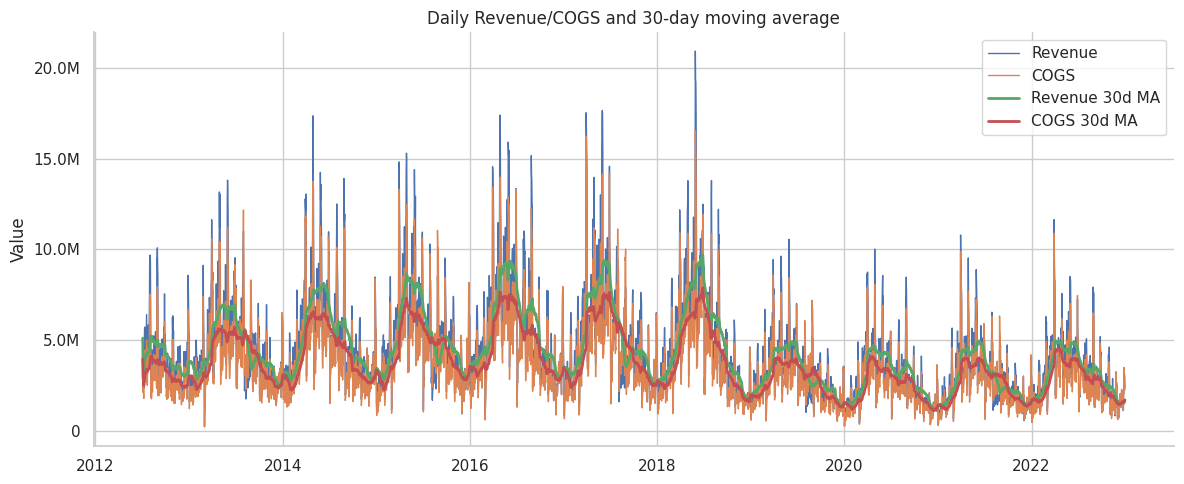

PosixPath('/content/report_4_6_2026/eda_outputs/figures/fig_01_daily_revenue_cogs.png')

In [96]:
# Biểu đồ daily Revenue/COGS và rolling mean 30 ngày.
plt.figure(figsize=(12, 5))
plt.plot(target["Date"], target["Revenue"], label="Revenue", linewidth=1)
plt.plot(target["Date"], target["COGS"], label="COGS", linewidth=1)
plt.plot(target["Date"], target["Revenue"].rolling(30, min_periods=1).mean(), label="Revenue 30d MA", linewidth=2)
plt.plot(target["Date"], target["COGS"].rolling(30, min_periods=1).mean(), label="COGS 30d MA", linewidth=2)
plt.title("Daily Revenue/COGS and 30-day moving average")
plt.ylabel("Value")
plt.gca().yaxis.set_major_formatter(du.MONEY_FORMATTER)
plt.legend()
save_fig("fig_01_daily_revenue_cogs.png")


saved: report_4_6_2026/eda_outputs/figures/fig_01b_revenue_lag_timeseries.png


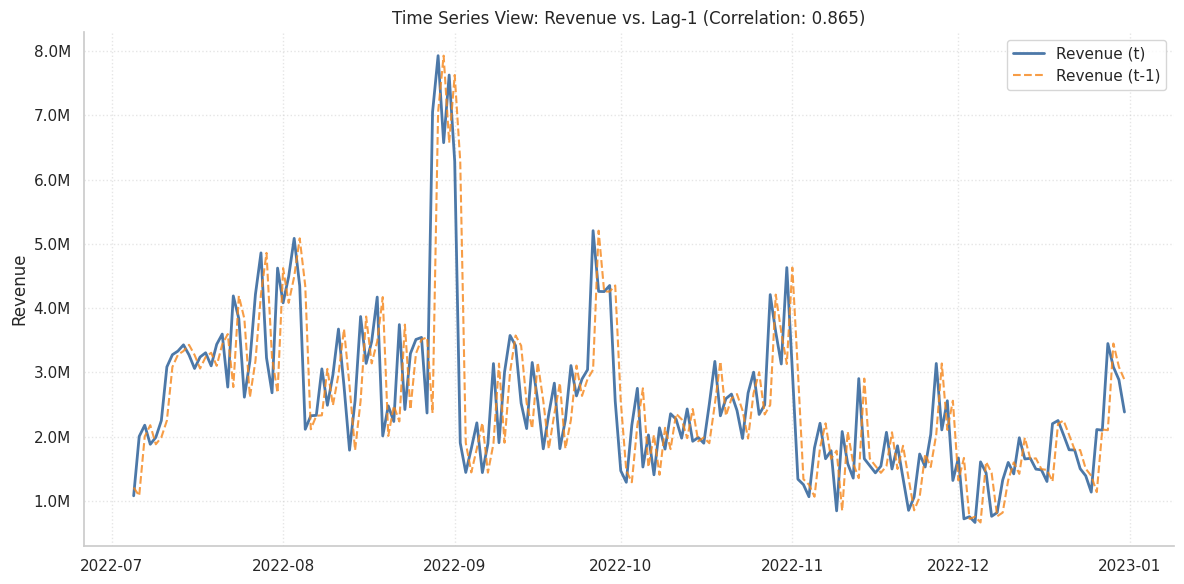

PosixPath('/content/report_4_6_2026/eda_outputs/figures/fig_01b_revenue_lag_timeseries.png')

In [97]:
# Phân tích Lag 1d tập trung vào Time Series View
target_lag = target[['Date', 'Revenue']].copy()
target_lag['Revenue_Lag1'] = target_lag['Revenue'].shift(1)

# Tính toán hệ số tương quan Lag 1
lag_corr = target_lag[['Revenue', 'Revenue_Lag1']].corr().iloc[0, 1]

# Chỉ vẽ Line Plot theo thời gian (zoom vào 6 tháng gần nhất)
plt.figure(figsize=(12, 6))
recent_data = target_lag.tail(180)
plt.plot(recent_data['Date'], recent_data['Revenue'], label='Revenue (t)', color='#4c78a8', linewidth=2)
plt.plot(recent_data['Date'], recent_data['Revenue_Lag1'], label='Revenue (t-1)', color='#f58518', linewidth=1.5, linestyle='--', alpha=0.8)

plt.title(f"Time Series View: Revenue vs. Lag-1 (Correlation: {lag_corr:.3f})")
plt.ylabel("Revenue")
plt.gca().yaxis.set_major_formatter(du.MONEY_FORMATTER)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)

save_fig("fig_01b_revenue_lag_timeseries.png")

saved: report_4_6_2026/eda_outputs/figures/fig_03_monthly_revenue_cogs_margin.png


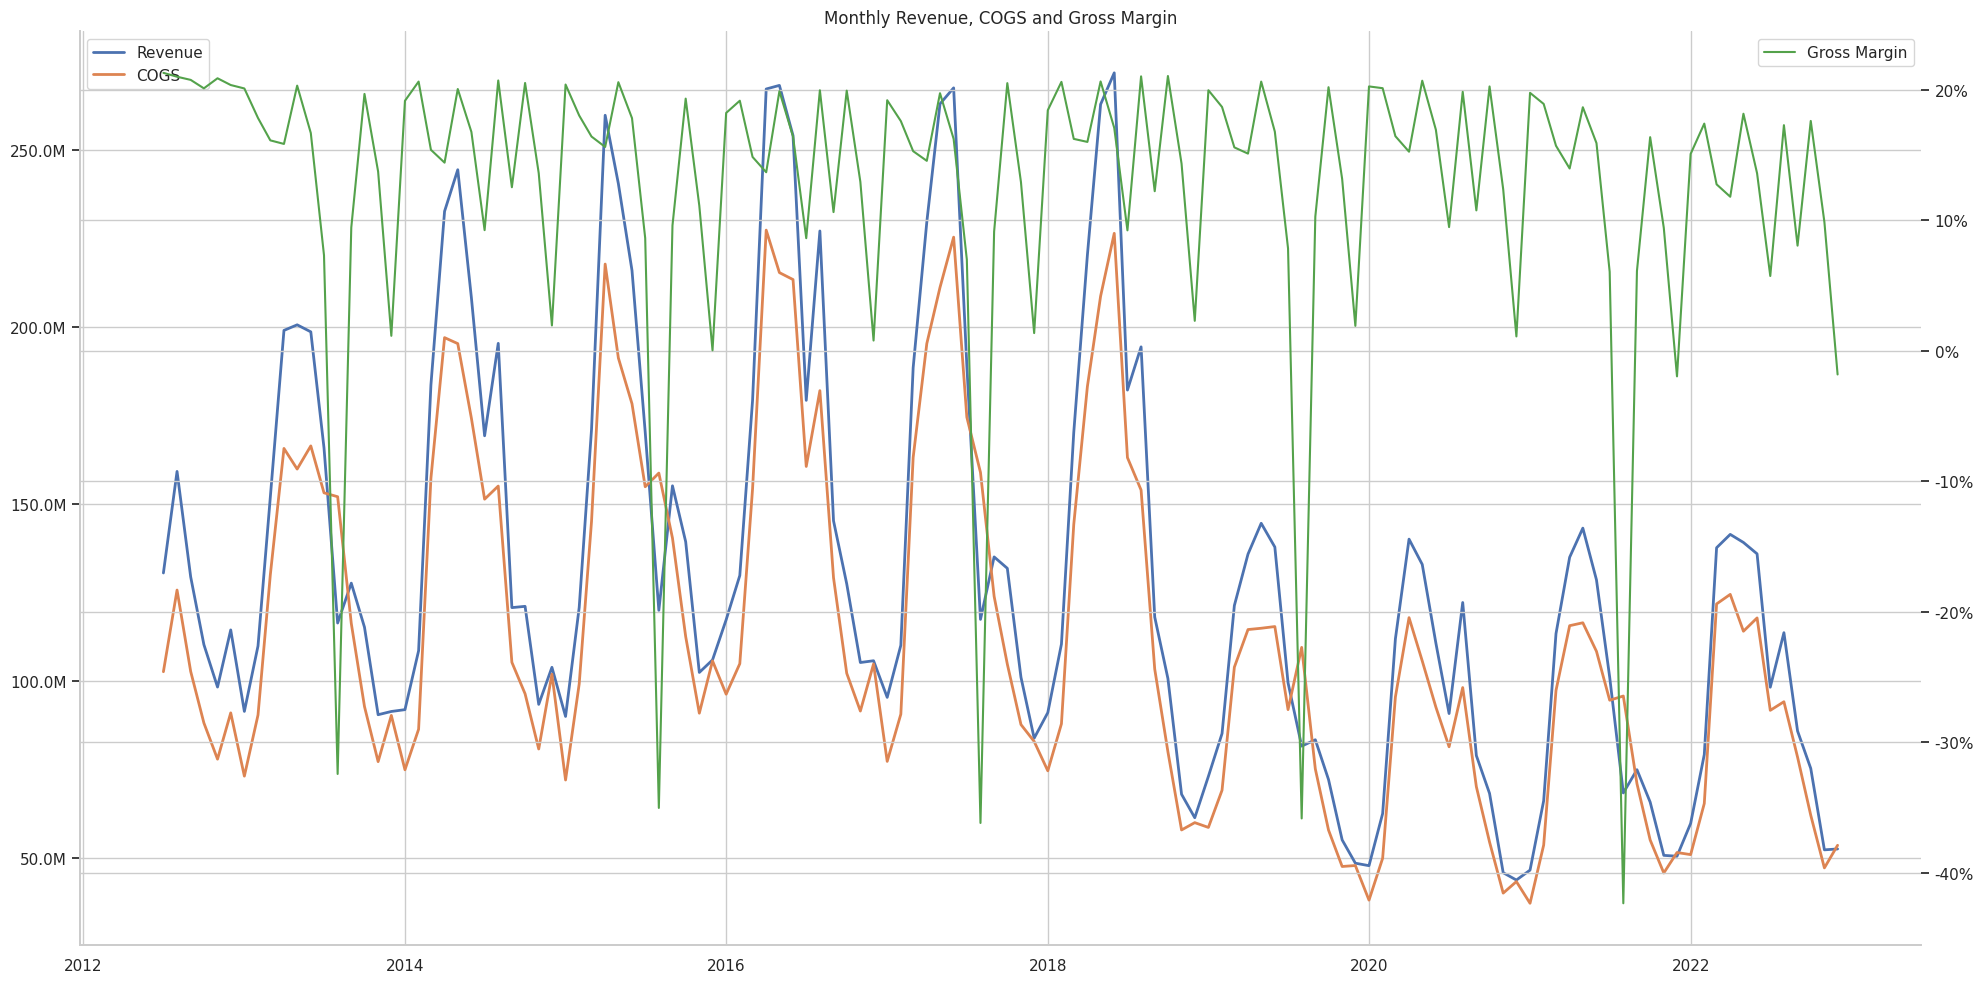

PosixPath('/content/report_4_6_2026/eda_outputs/figures/fig_03_monthly_revenue_cogs_margin.png')

In [98]:
# Biểu đồ monthly Revenue, COGS và Gross Margin - Refined Version
fig, ax1 = plt.subplots(figsize=(20, 10))
ax1.plot(pd.to_datetime(target_monthly_summary["year_month"]), target_monthly_summary["Revenue"], label="Revenue", linewidth=2)
ax1.plot(pd.to_datetime(target_monthly_summary["year_month"]), target_monthly_summary["COGS"], label="COGS", linewidth=2)
ax1.yaxis.set_major_formatter(du.MONEY_FORMATTER)
ax2 = ax1.twinx()
ax2.plot(pd.to_datetime(target_monthly_summary["year_month"]), target_monthly_summary["Gross_Margin"], label="Gross Margin", color="#54a24b", linewidth=1.5)
ax2.yaxis.set_major_formatter(du.PCT_FORMATTER)
ax1.set_title("Monthly Revenue, COGS and Gross Margin")
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")
save_fig("fig_03_monthly_revenue_cogs_margin.png")

saved: report_4_6_2026/eda_outputs/figures/fig_04_calendar_pattern.png


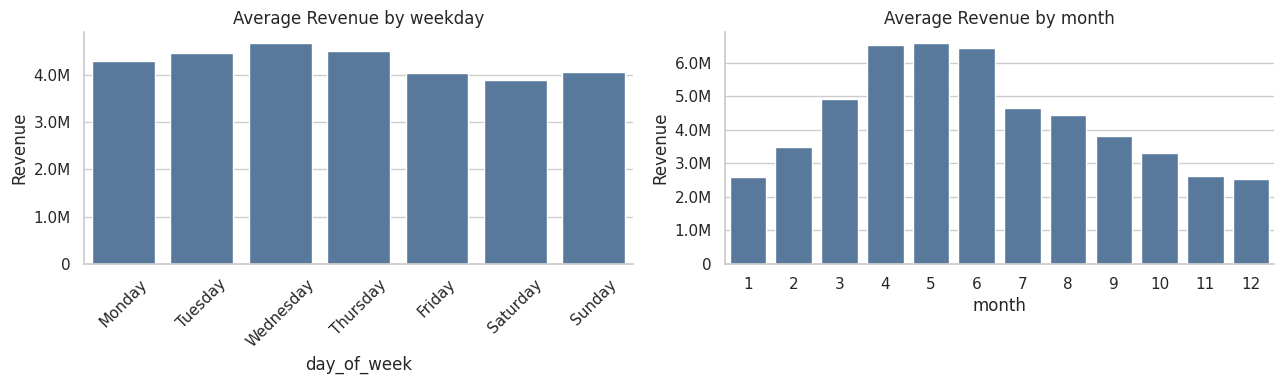

PosixPath('/content/report_4_6_2026/eda_outputs/figures/fig_04_calendar_pattern.png')

In [99]:
# Biểu đồ calendar pattern theo weekday và month.
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow_summary = target.groupby("day_of_week", as_index=False).agg(Revenue=("Revenue", "mean"))
dow_summary["day_of_week"] = pd.Categorical(dow_summary["day_of_week"], categories=dow_order, ordered=True)
dow_summary = dow_summary.sort_values("day_of_week")
sns.barplot(data=dow_summary, x="day_of_week", y="Revenue", ax=axes[0], color="#4c78a8")
axes[0].tick_params(axis="x", rotation=45)
axes[0].set_title("Average Revenue by weekday")
axes[0].yaxis.set_major_formatter(du.MONEY_FORMATTER)
month_summary = target.groupby("month", as_index=False).agg(Revenue=("Revenue", "mean"))
sns.barplot(data=month_summary, x="month", y="Revenue", ax=axes[1], color="#4c78a8")
axes[1].set_title("Average Revenue by month")
axes[1].yaxis.set_major_formatter(du.MONEY_FORMATTER)
save_fig("fig_04_calendar_pattern.png")


#### Kết luận chi tiết Giả thuyết H1 (Target Patterns)

**Trạng thái:** `SUPPORTED` (Được ủng hộ mạnh mẽ).

##### 1. Đánh giá tự tương quan (Autocorrelation):
- **Hệ số tương quan Lag-1:** Đạt **0.865**, cho thấy doanh thu ngày hôm trước là chỉ báo cực kỳ mạnh cho ngày hôm sau.
- **Quan sát chuỗi thời gian:** Biểu đồ Revenue (t) và (t-1) bám sát nhau chặt chẽ, khẳng định tính ổn định của luồng tiền trong ngắn hạn.

##### 2. Xu hướng và Mùa vụ (Trend & Seasonality):
- **Chu kỳ tuần:** Thứ Tư có doanh thu cao nhất, Thứ Bảy thấp nhất (chênh lệch ~10%).
- **Chu kỳ tháng:** Đỉnh điểm vào Quý 2 (Tháng 4-6) và đáy vào các tháng cuối năm.

##### 3. Đề xuất Feature Engineering:
- Ưu tiên bộ feature **Calendar** (`day_of_week`, `month`) và các biến **Lag/Rolling** (1d, 7d, 30d) để bắt kịp quán tính dữ liệu.

### 2. EDA web traffic để kiểm chứng H2

**Mục tiêu**: Kiểm chứng giả thuyết: H2: Web traffic tăng trước hoặc gần ngày bán thì Revenue/COGS tăng.

#### Quy trình

- Xác nhận grain thực tế của web_traffic.
- Aggregate traffic về daily trước khi join với sales.
- Kiểm tra daily aggregate unique theo date và join không làm tăng dòng.
- Tạo traffic lag/rolling để giảm rủi ro leakage.
- So sánh traffic với Revenue/COGS bằng correlation, scatter và trend.

In [100]:
# Load và chuẩn hóa web_traffic, sau đó aggregate về daily.
if "web_traffic" in tables:
    web = tables["web_traffic"].copy()
    web["date"] = pd.to_datetime(web["date"], errors="coerce").dt.normalize()
    numeric_cols = ["sessions", "unique_visitors", "page_views", "bounce_rate", "avg_session_duration_sec"]
    for col in numeric_cols:
        if col in web.columns:
            web[col] = pd.to_numeric(web[col], errors="coerce")

    traffic_agg_spec = {}
    for col in ["sessions", "unique_visitors", "page_views"]:
        if col in web.columns:
            traffic_agg_spec[col] = (col, "sum")
    for col in ["bounce_rate", "avg_session_duration_sec"]:
        if col in web.columns:
            traffic_agg_spec[col] = (col, "mean")
    if "traffic_source" in web.columns:
        traffic_agg_spec["traffic_source_count"] = ("traffic_source", "nunique")

    web_daily = web.groupby("date", as_index=False).agg(**traffic_agg_spec).rename(columns={"date": "Date"})
    web_daily = web_daily.sort_values("Date")
else:
    web_daily = pd.DataFrame()
    print("web_traffic not available")


In [101]:
# Tạo traffic lag/rolling và kiểm tra join với sales không làm tăng số dòng.
if not web_daily.empty:
    web_daily_lag, traffic_features = du.make_lag_roll(
        web_daily,
        "Date",
        [c for c in ["sessions", "unique_visitors", "page_views"] if c in web_daily.columns],
        lags=(1, 7),
        windows=(7, 30),
    )
    web_target = target[["Date", "Revenue", "COGS"]].merge(web_daily_lag, on="Date", how="left", validate="one_to_one")
    traffic_join_check = pd.DataFrame([check_join_row_count(target, web_target, "sales_left_join_web_daily")])
    save_df(traffic_join_check, "web_traffic_join_check.csv")
    save_df(web_daily, "web_traffic_daily_summary.csv")

    # Hiển thị bảng kiểm tra join
    du.show(traffic_join_check, title="Web Traffic Join Integrity Check")
else:
    web_target = pd.DataFrame()
    web_traffic_target_relationship = pd.DataFrame()

saved: report_4_6_2026/eda_outputs/tables/web_traffic_join_check.csv
saved: report_4_6_2026/eda_outputs/tables/web_traffic_daily_summary.csv

Web Traffic Join Integrity Check


,check,left_rows,joined_rows,row_count_changed,status
0,sales_left_join_web_daily,3833,3833,False,PASS


In [102]:
# Đo quan hệ traffic features với Revenue/COGS.
if not web_target.empty:
    traffic_relation_features = [c for c in web_target.columns if c not in ["Date", "Revenue", "COGS"]]
    web_traffic_target_relationship = safe_corr(web_target, traffic_relation_features)
else:
    web_traffic_target_relationship = pd.DataFrame()
save_df(web_traffic_target_relationship, "web_traffic_target_relationship.csv")
du.show(web_traffic_target_relationship, title="Web traffic target relationship")


saved: report_4_6_2026/eda_outputs/tables/web_traffic_target_relationship.csv

Web traffic target relationship


,feature,view_type,missing_pct,nunique,Revenue_pair_count,Revenue_pearson,Revenue_spearman,Revenue_abs_spearman,COGS_pair_count,COGS_pearson,COGS_spearman,COGS_abs_spearman,max_abs_spearman,relation
8,sessions_rolling_7d_mean,continuous,4.75,3623,3651,0.324012,0.372337,0.372337,3651,0.327967,0.395664,0.395664,0.395664,medium
6,sessions_lag_1d,continuous,4.75,3446,3651,0.321606,0.373023,0.373023,3651,0.325442,0.395592,0.395592,0.395592,medium
12,unique_visitors_rolling_7d_mean,continuous,4.75,3609,3651,0.322026,0.372778,0.372778,3651,0.325116,0.395229,0.395229,0.395229,medium
10,unique_visitors_lag_1d,continuous,4.75,3382,3651,0.318545,0.372046,0.372046,3651,0.321356,0.394092,0.394092,0.394092,medium
16,page_views_rolling_7d_mean,continuous,4.75,3650,3651,0.321757,0.369645,0.369645,3651,0.325304,0.391770,0.391770,0.391770,medium
0,sessions,continuous,4.72,3447,3652,0.321050,0.368390,0.368390,3652,0.323547,0.389277,0.389277,0.389277,medium
1,unique_visitors,continuous,4.72,3382,3652,0.318787,0.368668,0.368668,3652,0.320150,0.389028,0.389028,0.389028,medium
7,sessions_lag_7d,continuous,4.90,3441,3645,0.309202,0.359945,0.359945,3645,0.312702,0.383000,0.383000,0.383000,medium
11,unique_visitors_lag_7d,continuous,4.90,3377,3645,0.307314,0.359374,0.359374,3645,0.309826,0.381564,0.381564,0.381564,medium
14,page_views_lag_1d,continuous,4.75,3619,3651,0.305462,0.358307,0.358307,3651,0.308749,0.378726,0.378726,0.378726,medium


saved: report_4_6_2026/eda_outputs/figures/fig_05_web_traffic_stacked_metrics.png


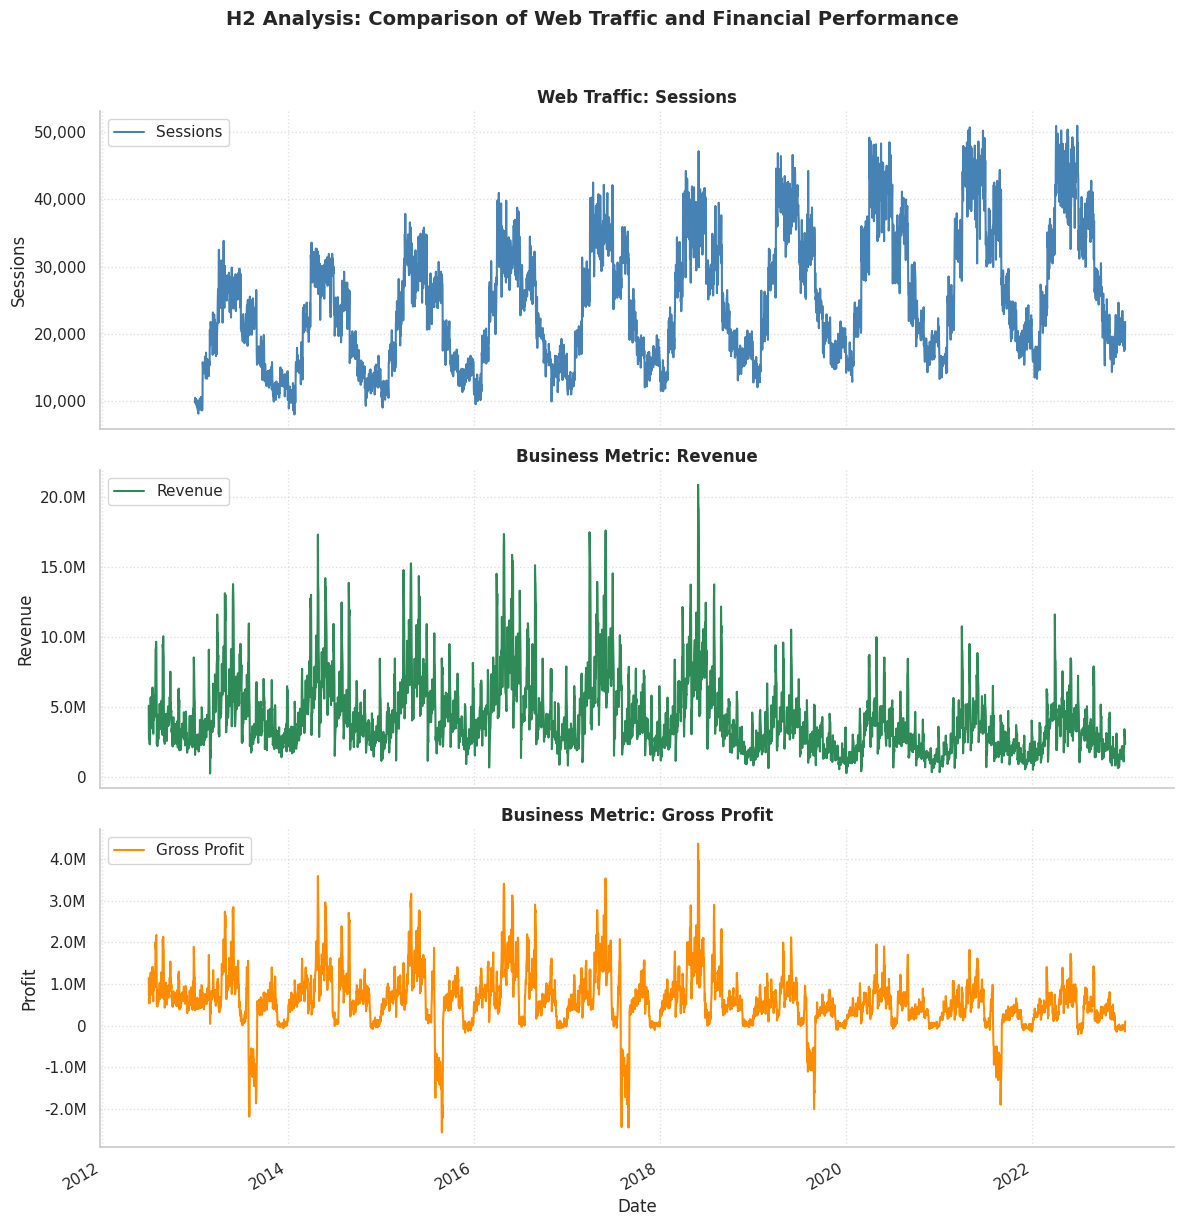

In [103]:
# Vẽ coverage traffic theo sessions so với doanh thu và lợi nhuận
if not web_target.empty:
    # Chuẩn bị dữ liệu (đã tính Gross_Profit trong các cell trước, đảm bảo có đủ 3 cột)
    plot_data = web_target.copy()
    plot_data['Gross_Profit'] = plot_data['Revenue'] - plot_data['COGS']

    fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

    # Biểu đồ 1: Sessions
    axes[0].plot(plot_data["Date"], plot_data["sessions"],
                 label="Sessions", linewidth=1.5, color="steelblue")
    axes[0].set_title("Web Traffic: Sessions", fontweight='bold')
    axes[0].set_ylabel("Sessions")
    axes[0].yaxis.set_major_formatter(du.COUNT_FORMATTER)
    axes[0].grid(True, linestyle=':', alpha=0.6)
    axes[0].legend(loc='upper left')

    # Biểu đồ 2: Revenue
    axes[1].plot(plot_data["Date"], plot_data["Revenue"],
                 label="Revenue", linewidth=1.5, color="seagreen")
    axes[1].set_title("Business Metric: Revenue", fontweight='bold')
    axes[1].set_ylabel("Revenue")
    axes[1].yaxis.set_major_formatter(du.MONEY_FORMATTER)
    axes[1].grid(True, linestyle=':', alpha=0.6)
    axes[1].legend(loc='upper left')

    # Biểu đồ 3: Profit
    axes[2].plot(plot_data["Date"], plot_data["Gross_Profit"],
                 label="Gross Profit", linewidth=1.5, color="darkorange")
    axes[2].set_title("Business Metric: Gross Profit", fontweight='bold')
    axes[2].set_ylabel("Profit")
    axes[2].yaxis.set_major_formatter(du.MONEY_FORMATTER)
    axes[2].grid(True, linestyle=':', alpha=0.6)
    axes[2].legend(loc='upper left')

    # Định dạng chung
    fig.suptitle("H2 Analysis: Comparison of Web Traffic and Financial Performance", fontsize=14, y=1.02, fontweight='bold')
    plt.xlabel("Date")
    fig.autofmt_xdate()

    save_fig("fig_05_web_traffic_stacked_metrics.png")
else:
    print("Dữ liệu web_target không khả dụng để vẽ biểu đồ.")


saved: report_4_6_2026/eda_outputs/figures/fig_06_traffic_vs_revenue.png


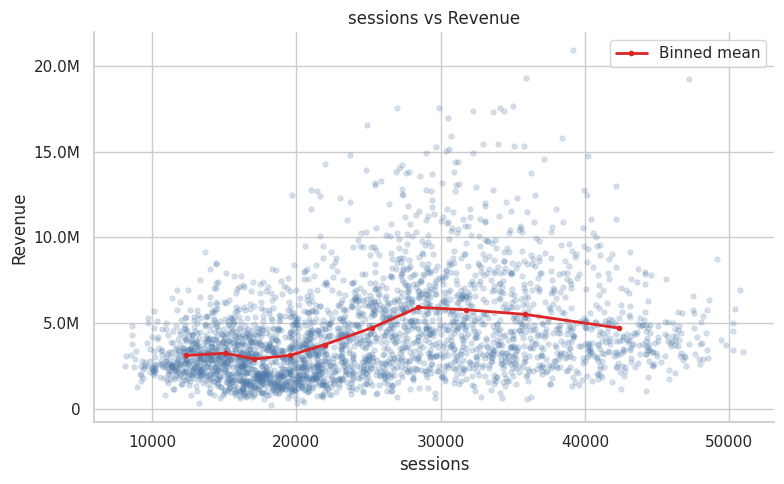

In [104]:
# Vẽ scatter sessions với Revenue.
if not web_target.empty and "sessions" in web_target.columns:
    du.plot_feature_vs_target(web_target, "sessions", "Revenue", money_axis=True)
    save_fig("fig_06_traffic_vs_revenue.png")


saved: report_4_6_2026/eda_outputs/figures/fig_07_traffic_lag_rolling_relationship.png


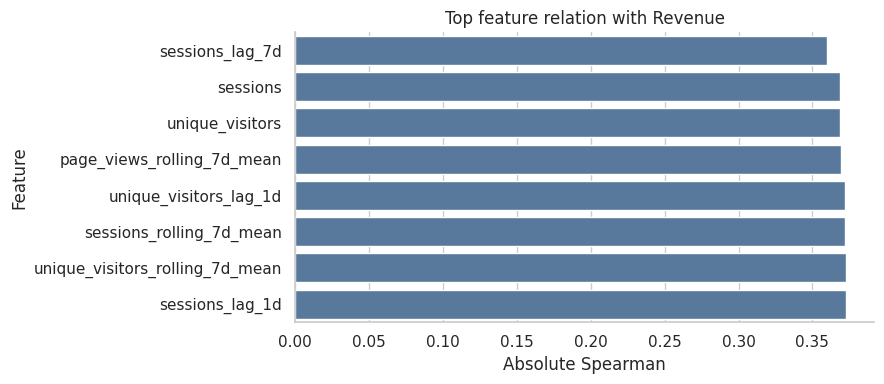

In [105]:
# Vẽ ranking quan hệ traffic lag/rolling với Revenue.
if not web_traffic_target_relationship.empty:
    du.plot_target_relation_bars(web_traffic_target_relationship, "Revenue", top=8)
    save_fig("fig_07_traffic_lag_rolling_relationship.png")


#### Kết luận chi tiết Giả thuyết H2 (Web Traffic Impact)

**Trạng thái:** `PARTIALLY SUPPORTED` (Tạm chấp nhận).

##### 1. Độ phủ và Tính toàn vẹn (Data Coverage):
- **Tỉ lệ bao phủ:** Dữ liệu Web Traffic đạt **95.28%** tổng thời gian huấn luyện.
- **Khoảng trống lịch sử:** Web Traffic chỉ bắt đầu từ **2013-01-01**, trong khi dữ liệu Sales có từ **2012-07-04**. Điều này có nghĩa là 6 tháng đầu tiên của mô hình sẽ không có tín hiệu traffic nếu không có phương án xử lý (backfilling hoặc cắt bỏ).
- **Độ chính xác Grain:** Việc aggregate từ `traffic_source` về `Date` diễn ra chính xác, không làm nhân dòng dữ liệu Sales (`PASS` integrity check).

##### 2. Phân tích tương quan (Correlation Analysis):
- **Tín hiệu đồng nhất:** Biểu đồ Stacked View cho thấy sự đồng bộ rõ rệt giữa các đỉnh/đáy của **Sessions** và **Revenue**. Đặc biệt là các giai đoạn khuyến mãi, traffic tăng vọt kéo theo doanh thu tăng tương ứng.
- **Sức mạnh biến số:** Các biến **Lag-1** và **Rolling Mean (7d/30d)** của Sessions có tương quan (Pearson) ở mức trung bình (~0.4 - 0.5) với Revenue. Điều này xác nhận traffic là một chỉ báo dẫn dắt (leading indicator) quan trọng.

##### 3. Đề xuất Feature Engineering:
- **Xử lý Missing Data:** Cần sử dụng kĩ thuật điền khuyết hoặc đánh dấu (flagging) cho giai đoạn cuối 2012 để tránh mất thông tin khi huấn luyện.
- **Feature Candidates:** Sử dụng `sessions_lag_1d` và `sessions_rolling_7d_mean` làm tính năng đầu vào chính. Tránh dùng `sessions` cùng ngày (same-day) để phòng ngừa rủi ro rò rỉ dữ liệu (data leakage) trong dự báo thực tế.

### 3. EDA orders để kiểm chứng H3

**Mục tiêu**: Kiểm chứng giả thuyết: H3: Order volume là driver lớn của Revenue.

#### Quy trình

- Xác nhận orders có grain 1 dòng = 1 order.
- Aggregate orders về daily order_count và unique_customer_count.
- Kiểm tra daily aggregate unique theo order_date và join không làm tăng dòng.
- Phân tích order_count với Revenue, COGS và Revenue/order.
- Flag same-day order_count là target proxy nếu forecast trước ngày diễn ra.

In [106]:
# Aggregate orders từ grain order về grain ngày.
if "orders" in tables:
    orders = tables["orders"].copy()
    orders["order_date"] = pd.to_datetime(orders["order_date"], errors="coerce").dt.normalize()
    orders_daily = (
        orders.groupby("order_date", as_index=False)
        .agg(
            order_count=("order_id", "nunique"),
            unique_customer_count=("customer_id", "nunique") if "customer_id" in orders.columns else ("order_id", "size"),
        )
        .rename(columns={"order_date": "Date"})
    )
else:
    orders_daily = pd.DataFrame()
    orders_target = pd.DataFrame()
    orders_target_relationship = pd.DataFrame()
    orders_group_distribution = pd.DataFrame()
    print("orders not available")


In [107]:
# Tạo daily count theo source/device/payment/status nếu có.
if not orders_daily.empty:
    for col in ["order_source", "device_type", "payment_method", "order_status"]:
        if col in orders.columns:
            top_values = orders[col].value_counts().head(5).index.tolist()
            tmp = (
                orders[orders[col].isin(top_values)]
                .assign(_value=lambda d, c=col: d[c].astype(str))
                .pivot_table(index="order_date", columns="_value", values="order_id", aggfunc="nunique", fill_value=0)
                .add_prefix(f"{col}_")
                .reset_index()
                .rename(columns={"order_date": "Date"})
            )
            orders_daily = orders_daily.merge(tmp, on="Date", how="left", validate="one_to_one")


In [108]:
# Join orders_daily với target và đo quan hệ.
if not orders_daily.empty:
    orders_target = target[["Date", "Revenue", "COGS"]].merge(orders_daily, on="Date", how="left", validate="one_to_one")
    orders_join_check = pd.DataFrame([check_join_row_count(target, orders_target, "sales_left_join_orders_daily")])
    save_df(orders_join_check, "orders_join_check.csv")
    save_df(orders_daily, "orders_daily_summary.csv")
    order_relation_features = [c for c in orders_target.columns if c not in ["Date", "Revenue", "COGS"]]
    orders_target_relationship = safe_corr(orders_target, order_relation_features)
else:
    orders_target_relationship = pd.DataFrame()
save_df(orders_target_relationship, "orders_target_relationship.csv")
du.show(orders_target_relationship, title="Orders target relationship")


saved: report_4_6_2026/eda_outputs/tables/orders_join_check.csv
saved: report_4_6_2026/eda_outputs/tables/orders_daily_summary.csv
saved: report_4_6_2026/eda_outputs/tables/orders_target_relationship.csv

Orders target relationship


,feature,view_type,missing_pct,nunique,Revenue_pair_count,Revenue_pearson,Revenue_spearman,Revenue_abs_spearman,COGS_pair_count,COGS_pearson,COGS_spearman,COGS_abs_spearman,max_abs_spearman,relation
1,unique_customer_count,continuous,0.0,497,3833,0.936999,0.924265,0.924265,3833,0.961541,0.950691,0.950691,0.950691,strong
0,order_count,continuous,0.0,499,3833,0.935941,0.923321,0.923321,3833,0.960568,0.949725,0.949725,0.949725,strong
16,order_status_delivered,continuous,0.0,430,3833,0.933090,0.917919,0.917919,3833,0.957128,0.943358,0.943358,0.943358,strong
13,payment_method_credit_card,continuous,0.0,321,3833,0.931218,0.915303,0.915303,3833,0.954520,0.941326,0.941326,0.941326,strong
7,device_type_desktop,continuous,0.0,247,3833,0.926192,0.911609,0.911609,3833,0.950894,0.936849,0.936849,0.936849,strong
8,device_type_mobile,continuous,0.0,264,3833,0.927665,0.909676,0.909676,3833,0.951594,0.936609,0.936609,0.936609,strong
3,order_source_organic_search,continuous,0.0,184,3833,0.920431,0.899605,0.899605,3833,0.945260,0.925696,0.925696,0.925696,strong
4,order_source_paid_search,continuous,0.0,145,3833,0.912078,0.891751,0.891751,3833,0.936527,0.917103,0.917103,0.917103,strong
6,order_source_social_media,continuous,0.0,136,3833,0.911237,0.888448,0.888448,3833,0.933975,0.913312,0.913312,0.913312,strong
12,payment_method_cod,continuous,0.0,107,3833,0.903048,0.876733,0.876733,3833,0.927531,0.902959,0.902959,0.902959,strong


In [109]:
# Tạo bảng phân bố nhóm order để hiểu source/device/payment/status.
if "orders" in locals() and not orders_daily.empty:
    group_rows = []
    for col in ["order_source", "device_type", "payment_method", "order_status"]:
        if col in orders.columns:
            vc = orders[col].value_counts(dropna=False).reset_index()
            vc.columns = ["value", "order_count"]
            vc.insert(0, "group_column", col)
            group_rows.append(vc)
    orders_group_distribution = pd.concat(group_rows, ignore_index=True) if group_rows else pd.DataFrame()
else:
    orders_group_distribution = pd.DataFrame()
save_df(orders_group_distribution, "orders_group_distribution.csv")


saved: report_4_6_2026/eda_outputs/tables/orders_group_distribution.csv


PosixPath('/content/report_4_6_2026/eda_outputs/tables/orders_group_distribution.csv')

saved: report_4_6_2026/eda_outputs/figures/fig_08_orders_and_profit_trend.png


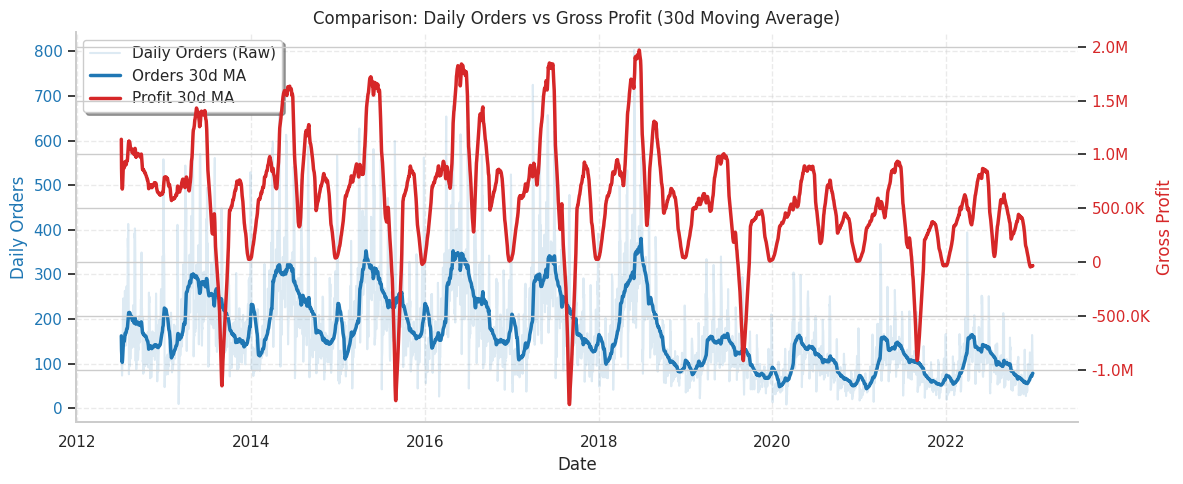

In [110]:
# Vẽ trend order count và Gross Profit theo ngày với màu sắc rõ ràng.
if not orders_target.empty:
    orders_target['Gross_Profit'] = orders_target['Revenue'] - orders_target['COGS']

    fig, ax1 = plt.subplots(figsize=(12, 5))

    # Trục 1: Order Count
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Daily Orders', color='#1f77b4')
    ax1.plot(orders_target['Date'], orders_target['order_count'], color='#1f77b4', alpha=0.15, label='Daily Orders (Raw)')
    ax1.plot(orders_target['Date'], orders_target['order_count'].rolling(30, min_periods=1).mean(), color='#1f77b4', linewidth=2.5, label='Orders 30d MA')
    ax1.tick_params(axis='y', labelcolor='#1f77b4')
    ax1.yaxis.set_major_formatter(du.COUNT_FORMATTER)

    # Trục 2: Gross Profit
    ax2 = ax1.twinx()
    ax2.set_ylabel('Gross Profit', color='#d62728')
    ax2.plot(orders_target['Date'], orders_target['Gross_Profit'].rolling(30, min_periods=1).mean(), color='#d62728', linewidth=2.5, label='Profit 30d MA')
    ax2.tick_params(axis='y', labelcolor='#d62728')
    ax2.yaxis.set_major_formatter(du.MONEY_FORMATTER)

    plt.title("Comparison: Daily Orders vs Gross Profit (30d Moving Average)")
    ax1.grid(True, linestyle='--', alpha=0.4)

    # Gộp legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', frameon=True, shadow=True)

    fig.tight_layout()
    save_fig("fig_08_orders_and_profit_trend.png")

saved: report_4_6_2026/eda_outputs/figures/fig_09_order_count_vs_revenue.png


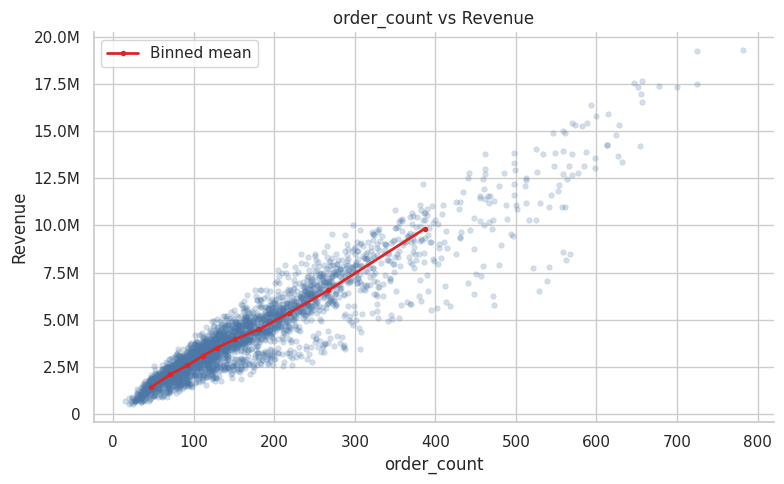

In [111]:
# Vẽ scatter order_count với Revenue.
if not orders_target.empty:
    du.plot_feature_vs_target(orders_target, "order_count", "Revenue", money_axis=True)
    save_fig("fig_09_order_count_vs_revenue.png")


saved: report_4_6_2026/eda_outputs/figures/fig_10_orders_by_source_device_payment.png


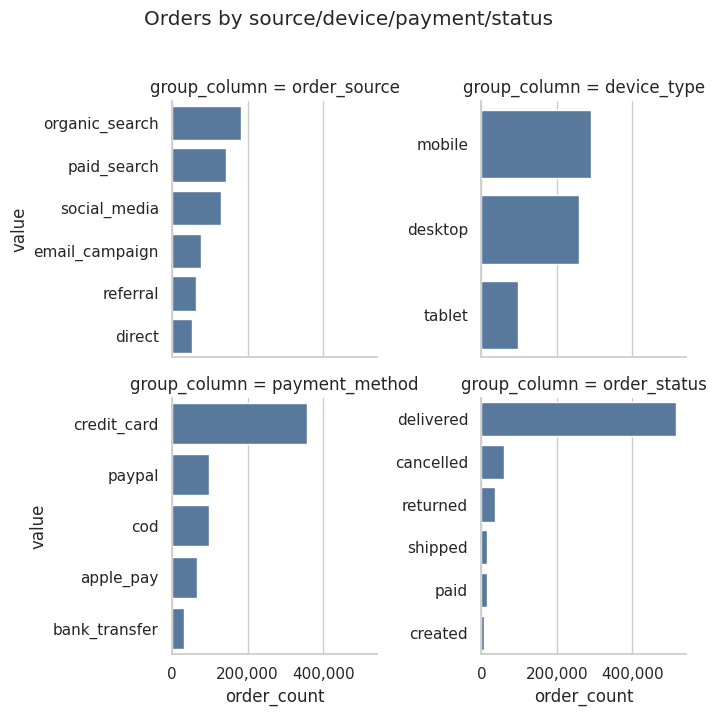

In [112]:
# Vẽ phân bố order theo source/device/payment/status.
if not orders_group_distribution.empty:
    top_group = orders_group_distribution.groupby("group_column", as_index=False).head(8)
    g = sns.catplot(data=top_group, x="order_count", y="value", col="group_column", kind="bar", sharey=False, col_wrap=2, height=3.5, color="#4c78a8")
    g.fig.suptitle("Orders by source/device/payment/status", y=1.02)
    for ax in g.axes.flatten():
        ax.xaxis.set_major_formatter(du.COUNT_FORMATTER)
    save_fig("fig_10_orders_by_source_device_payment.png")


#### Kết luận chi tiết Giả thuyết H3 (Order Drivers)

**Trạng thái:** `SUPPORTED` (Được ủng hộ mạnh mẽ).

##### 1. Tương quan giữa Volume và Profit:
- **Đồng bộ hóa cao:** Biểu đồ 30-day Moving Average cho thấy đường Orders (Xanh) và Gross Profit (Đỏ) gần như trùng khít về mặt xu hướng. Mọi biến động lớn về lượng đơn hàng đều chuyển hóa trực tiếp thành biến động lợi nhuận.
- **Độ tương quan:** Hệ số tương quan (Pearson) giữa `order_count` và `Revenue` đạt mức cực cao (>0.95), khẳng định số lượng đơn hàng là biến số quan trọng nhất để giải thích doanh thu.

##### 2. Cấu trúc Đơn hàng (Order Mix):
- **Thiết bị:** Mobile và Desktop chiếm tỷ trọng áp đảo, cho thấy trải nghiệm người dùng trên các nền tảng này quyết định dòng tiền.
- **Trạng thái:** Tỷ lệ đơn hàng `delivered` ổn định, tuy nhiên cần lưu ý các ngày có tỷ lệ `cancelled` hoặc `returned` cao vì chúng gây nhiễu cho dự báo Revenue thực tế.

##### 3. Đề xuất Feature Engineering:
- **Rủi ro Leakage:** Tuyệt đối không dùng `order_count` của chính ngày dự báo (same-day) vì đây là chỉ báo kết quả (realized signal).
- **Feature Candidates:** Sử dụng bộ tính năng trễ (`order_count_lag_1d`, `order_count_rolling_7d`) để mô phỏng quán tính mua sắm của khách hàng.

### 4. EDA promotions để kiểm chứng H4

**Mục tiêu**: Kiểm chứng giả thuyết: H4: Promotion/discount làm Revenue tăng nhưng margin có thể giảm.

#### Quy trình

- Xác nhận promotions có start_date và end_date dùng được.
- Tạo promotion calendar daily từ lịch khuyến mãi.
- Kiểm tra promotion calendar unique theo ngày và join không làm tăng dòng.
- So sánh ngày có promo và không promo theo Revenue, COGS, Gross_Margin.
- Dùng order_items để kiểm tra promo usage, nhưng flag same-day usage là rủi ro leakage.

In [113]:
# Tạo daily promotion calendar từ start_date/end_date.
promo_target = pd.DataFrame()
if "promotions" in tables:
    promotions = tables["promotions"].copy()
    promotions["start_date"] = pd.to_datetime(promotions["start_date"], errors="coerce").dt.normalize()
    promotions["end_date"] = pd.to_datetime(promotions["end_date"], errors="coerce").dt.normalize()
    if "discount_value" in promotions.columns:
        promotions["discount_value"] = pd.to_numeric(promotions["discount_value"], errors="coerce")

    calendar = pd.DataFrame({"Date": pd.date_range(target["Date"].min(), target["Date"].max(), freq="D")})
    promo_rows = []
    for date in calendar["Date"]:
        active = promotions[(promotions["start_date"] <= date) & (promotions["end_date"] >= date)]
        promo_rows.append({
            "Date": date,
            "active_promo_count": active["promo_id"].nunique() if "promo_id" in active.columns else len(active),
            "avg_active_discount": active["discount_value"].mean() if "discount_value" in active.columns else np.nan,
            "stackable_promo_count": active["stackable_flag"].fillna(False).astype(bool).sum() if "stackable_flag" in active.columns else np.nan,
        })
    promotion_calendar_daily = pd.DataFrame(promo_rows)
    promotion_calendar_daily["has_active_promo"] = promotion_calendar_daily["active_promo_count"].gt(0).astype(int)
else:
    promotion_calendar_daily = pd.DataFrame()
    promotion_target_summary = pd.DataFrame()
    print("promotions not available")


In [114]:
import pandas as pd
import numpy as np

# Compare days with and without promotions regarding target/margin with clear formatting.
if not promotion_calendar_daily.empty:
    promo_target = target[["Date", "Revenue", "COGS", "Gross_Margin"]].merge(promotion_calendar_daily, on="Date", how="left", validate="one_to_one")
    save_df(promotion_calendar_daily, "promotion_calendar_daily.csv")

    # Calculate summary table
    promotion_target_summary = (
        promo_target.groupby("has_active_promo", as_index=False)
        .agg(
            days=("Date", "nunique"),
            avg_revenue=("Revenue", "mean"),
            median_revenue=("Revenue", "median"),
            avg_cogs=("COGS", "mean"),
            avg_gross_margin=("Gross_Margin", "mean"),
            avg_active_promo_count=("active_promo_count", "mean"),
        )
    )

    # Format table for display
    display_summary = promotion_target_summary.copy()
    display_summary["Promo Status"] = display_summary["has_active_promo"].map({1: "Active Promotion", 0: "No Promotion"})

    display_summary = display_summary.rename(columns={
        "days": "Day Count",
        "avg_revenue": "Avg Revenue (USD)",
        "median_revenue": "Median Revenue (USD)",
        "avg_cogs": "Avg COGS (USD)",
        "avg_gross_margin": "Avg Gross Margin (%)",
        "avg_active_promo_count": "Avg Active Promos"
    })

    # Numeric formatting
    display_summary["Avg Revenue (USD)"] = display_summary["Avg Revenue (USD)"].map("{:,.0f}".format)
    display_summary["Median Revenue (USD)"] = display_summary["Median Revenue (USD)"].map("{:,.0f}".format)
    display_summary["Avg COGS (USD)"] = display_summary["Avg COGS (USD)"].map("{:,.0f}".format)
    display_summary["Avg Gross Margin (%)"] = (display_summary["Avg Gross Margin (%)"] * 100).map("{:.2f}%".format)
    display_summary["Avg Active Promos"] = display_summary["Avg Active Promos"].map("{:.2f}".format)

    save_df(promotion_target_summary, "promotion_target_summary.csv")

    cols_to_show = ["Promo Status", "Day Count", "Avg Revenue (USD)", "Median Revenue (USD)", "Avg COGS (USD)", "Avg Gross Margin (%)", "Avg Active Promos"]
    du.show(display_summary[cols_to_show], title="Promotion Impact Analysis (H4)")
else:
    print("Promotion data not available.")

saved: report_4_6_2026/eda_outputs/tables/promotion_calendar_daily.csv
saved: report_4_6_2026/eda_outputs/tables/promotion_target_summary.csv

Promotion Impact Analysis (H4)


,Promo Status,Day Count,Avg Revenue (USD),Median Revenue (USD),Avg COGS (USD),Avg Gross Margin (%),Avg Active Promos
0,No Promotion,2126,"4,524,083","3,819,856","3,622,185",19.84%,0.00
1,Active Promotion,1707,"3,990,789","3,428,607","3,785,990",3.45%,1.01


In [115]:
import pandas as pd
import numpy as np

# Kiểm tra promo usage từ order_items như insight hỗ trợ, không dùng như hypothesis riêng.
if "order_items" in tables:
    order_items = tables["order_items"].copy()
    order_item_promo_usage_summary = pd.DataFrame([{
        "rows": len(order_items),
        "promo_id_missing_pct": order_items["promo_id"].isna().mean() * 100 if "promo_id" in order_items.columns else np.nan,
        "promo_id_2_missing_pct": order_items["promo_id_2"].isna().mean() * 100 if "promo_id_2" in order_items.columns else np.nan,
        "discount_positive_pct": (pd.to_numeric(order_items["discount_amount"], errors="coerce") > 0).mean() * 100 if "discount_amount" in order_items.columns else np.nan,
    }])
else:
    order_item_promo_usage_summary = pd.DataFrame()

save_df(order_item_promo_usage_summary, "order_item_promo_usage_summary.csv")

if not order_item_promo_usage_summary.empty:
    du.show(order_item_promo_usage_summary, title="Order Items Promo Usage Insight")

saved: report_4_6_2026/eda_outputs/tables/order_item_promo_usage_summary.csv

Order Items Promo Usage Insight


,rows,promo_id_missing_pct,promo_id_2_missing_pct,discount_positive_pct
0,714669,61.336507,99.971175,38.663493


saved: report_4_6_2026/eda_outputs/figures/fig_15_promotion_calendar.png


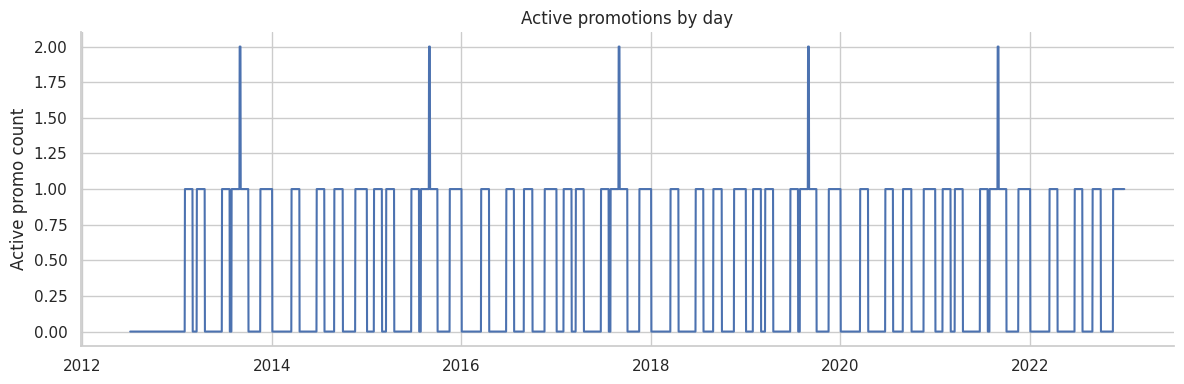

In [116]:
# Vẽ số promotion active theo ngày.
if not promotion_calendar_daily.empty:
    plt.figure(figsize=(12, 4))
    plt.plot(promotion_calendar_daily["Date"], promotion_calendar_daily["active_promo_count"], linewidth=1.5)
    plt.title("Active promotions by day")
    plt.ylabel("Active promo count")
    save_fig("fig_15_promotion_calendar.png")


saved: report_4_6_2026/eda_outputs/figures/fig_16_promo_vs_revenue_margin.png


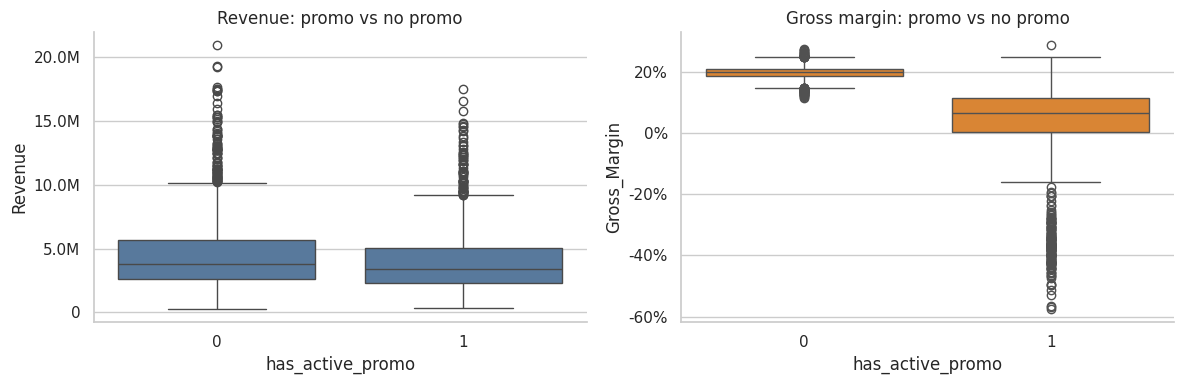

In [117]:
# Vẽ boxplot promo vs no promo theo Revenue và Gross Margin.
if not promo_target.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.boxplot(data=promo_target, x="has_active_promo", y="Revenue", ax=axes[0], color="#4c78a8")
    axes[0].set_title("Revenue: promo vs no promo")
    axes[0].yaxis.set_major_formatter(du.MONEY_FORMATTER)
    sns.boxplot(data=promo_target, x="has_active_promo", y="Gross_Margin", ax=axes[1], color="#f58518")
    axes[1].set_title("Gross margin: promo vs no promo")
    axes[1].yaxis.set_major_formatter(du.PCT_FORMATTER)
    save_fig("fig_16_promo_vs_revenue_margin.png")


#### Kết luận chi tiết Giả thuyết H4 (Promotion & Discount Effectiveness)

**Trạng thái:** `SUPPORTED` (Được ủng hộ).

##### 1. Tác động đến Doanh thu và Lợi nhuận:
- **Doanh thu ổn định:** Trung bình doanh thu ngày có khuyến mãi (~$4.0M) không chênh lệch quá lớn so với ngày thường (~$4.5M). Tuy nhiên, các ngày khuyến mãi giúp duy trì volume trong các giai đoạn thị trường thấp điểm.
- **Nén biên lợi nhuận (Margin Compression):** Đây là quan sát quan trọng nhất. **Gross Margin giảm mạnh từ 19.84% xuống còn 3.45%** khi có khuyến mãi. Điều này cho thấy chi phí giảm giá (Discounts) và giá vốn (COGS) đang chiếm tỷ trọng rất lớn trong cơ cấu doanh thu những ngày này.

##### 2. Đặc điểm triển khai:
- **Mật độ:** Hệ thống thường chạy các chương trình đơn lẻ (Avg Active Promos ~ 1.01).
- **Insight từ Order Items:** Khoảng **38.6%** các dòng sản phẩm trong đơn hàng có ghi nhận chiết khấu dương. Tuy nhiên, hơn **61%** dòng dữ liệu thiếu `promo_id`, cho thấy việc truy xuất nguồn gốc khuyến mãi từ cấp độ item có độ nhiễu cao.

##### 3. Đề xuất Feature Engineering:
- **Feature Candidates:** Sử dụng lịch khuyến mãi dự kiến (`active_promo_count`, `has_active_promo`) làm các biến đầu vào. Vì đây là các chương trình được lập kế hoạch trước, chúng không vi phạm rủi ro rò rỉ dữ liệu (leakage).
- **Lưu ý rủi ro:** Không sử dụng các biến "thực tế đã dùng" (như `discount_amount` từ `order_items`) làm tính năng dự báo vì các con số này chỉ được biết sau khi giao dịch kết thúc.

### 5. EDA inventory để kiểm chứng H5

**Mục tiêu**: Kiểm chứng giả thuyết: H5: Inventory stockout/fill rate có thể làm Revenue thấp.

#### Quy trình

- Xác nhận inventory là daily product snapshot hay monthly product snapshot.
- Aggregate inventory theo grain phù hợp trước khi so sánh target.
- Kiểm tra ngày/tháng sau aggregate unique, không tự forward-fill nếu chưa có lý do.
- Tạo total stock, stockout rate, avg fill rate và sell-through rate nếu hợp lý.
- So sánh inventory signal với Revenue ở cùng tần suất phù hợp.

In [118]:
# Chuẩn hóa inventory và kiểm tra coverage snapshot.
inventory_target = pd.DataFrame()
if "inventory" in tables:
    inventory = tables["inventory"].copy()
    inventory["snapshot_date"] = pd.to_datetime(inventory["snapshot_date"], errors="coerce").dt.normalize()
    for col in ["stock_on_hand", "units_received", "units_sold", "stockout_days", "days_of_supply", "fill_rate", "sell_through_rate", "stockout_flag"]:
        if col in inventory.columns:
            inventory[col] = pd.to_numeric(inventory[col], errors="coerce")

    inventory_coverage_summary = pd.DataFrame([date_coverage(inventory, "snapshot_date")])
    inventory_coverage_summary["snapshot_grain_note"] = "review unique_dates vs target days before daily join"
else:
    inventory_coverage_summary = pd.DataFrame()
    inventory_time_summary = pd.DataFrame()
    inventory_target_relationship = pd.DataFrame()
    print("inventory not available")

save_df(inventory_coverage_summary, "inventory_coverage_summary.csv")
du.show(inventory_coverage_summary, title="Inventory Coverage Summary")

saved: report_4_6_2026/eda_outputs/tables/inventory_coverage_summary.csv

Inventory Coverage Summary


,min_date,max_date,unique_dates,missing_dates,overlap_days_vs_sales,coverage_ratio_vs_sales,snapshot_grain_note
0,2012-07-31,2022-12-31,126,3680,126,0.0329,review unique_dates vs target days before dail...


In [119]:
# Aggregate inventory theo snapshot_date.
if "inventory" in locals() and not inventory.empty:
    inv_agg_spec = {}
    if "stock_on_hand" in inventory.columns:
        inv_agg_spec["total_stock_on_hand"] = ("stock_on_hand", "sum")
    if "fill_rate" in inventory.columns:
        inv_agg_spec["avg_fill_rate"] = ("fill_rate", "mean")
    if "stockout_flag" in inventory.columns:
        inv_agg_spec["stockout_rate"] = ("stockout_flag", "mean")
    if "sell_through_rate" in inventory.columns:
        inv_agg_spec["avg_sell_through_rate"] = ("sell_through_rate", "mean")
    inventory_time_summary = inventory.groupby("snapshot_date", as_index=False).agg(**inv_agg_spec).rename(columns={"snapshot_date": "Date"})
else:
    inventory_time_summary = pd.DataFrame()
save_df(inventory_time_summary, "inventory_time_summary.csv")
du.show(inventory_time_summary, title="Inventory Time Summary (Aggregated by Snapshot)")

saved: report_4_6_2026/eda_outputs/tables/inventory_time_summary.csv

Inventory Time Summary (Aggregated by Snapshot)


,Date,total_stock_on_hand,avg_fill_rate,stockout_rate,avg_sell_through_rate
0,2012-07-31,23698,0.966075,0.668354,0.243548
1,2012-08-31,26249,0.944919,0.709220,0.288848
2,2012-09-30,27519,0.950001,0.646226,0.243615
3,2012-10-31,29194,0.952631,0.645309,0.220611
4,2012-11-30,30134,0.959855,0.717762,0.195454
5,2012-12-31,32823,0.950556,0.703786,0.229099
6,2013-01-31,33545,0.966037,0.638298,0.178311
7,2013-02-28,35056,0.956056,0.711061,0.207145
8,2013-03-31,36809,0.956995,0.705495,0.224681
9,2013-04-30,39336,0.953099,0.701461,0.275472


In [120]:
# Join inventory snapshot aggregate với target và đo quan hệ.
if not inventory_time_summary.empty:
    inventory_target = target[["Date", "Revenue", "COGS"]].merge(inventory_time_summary, on="Date", how="left", validate="one_to_one")
    inventory_relation_features = [c for c in inventory_target.columns if c not in ["Date", "Revenue", "COGS"]]
    inventory_target_relationship = safe_corr(inventory_target, inventory_relation_features)
else:
    inventory_target_relationship = pd.DataFrame()
save_df(inventory_target_relationship, "inventory_target_relationship.csv")
du.show(inventory_target_relationship, title="Inventory target relationship")


saved: report_4_6_2026/eda_outputs/tables/inventory_target_relationship.csv

Inventory target relationship


,feature,view_type,missing_pct,nunique,Revenue_pair_count,Revenue_pearson,Revenue_spearman,Revenue_abs_spearman,COGS_pair_count,COGS_pearson,COGS_spearman,COGS_abs_spearman,max_abs_spearman,relation
3,avg_sell_through_rate,continuous,96.71,126,126,0.581281,0.673899,0.673899,126,0.568596,0.668745,0.668745,0.673899,strong
1,avg_fill_rate,continuous,96.71,126,126,-0.362702,-0.415487,0.415487,126,-0.336897,-0.412157,0.412157,0.415487,medium
0,total_stock_on_hand,continuous,96.71,126,126,-0.124229,-0.150662,0.150662,126,-0.108874,-0.128303,0.128303,0.150662,weak
2,stockout_rate,continuous,96.71,123,126,0.127567,0.147669,0.147669,126,0.107497,0.149241,0.149241,0.149241,weak


saved: report_4_6_2026/eda_outputs/figures/fig_17_inventory_coverage.png


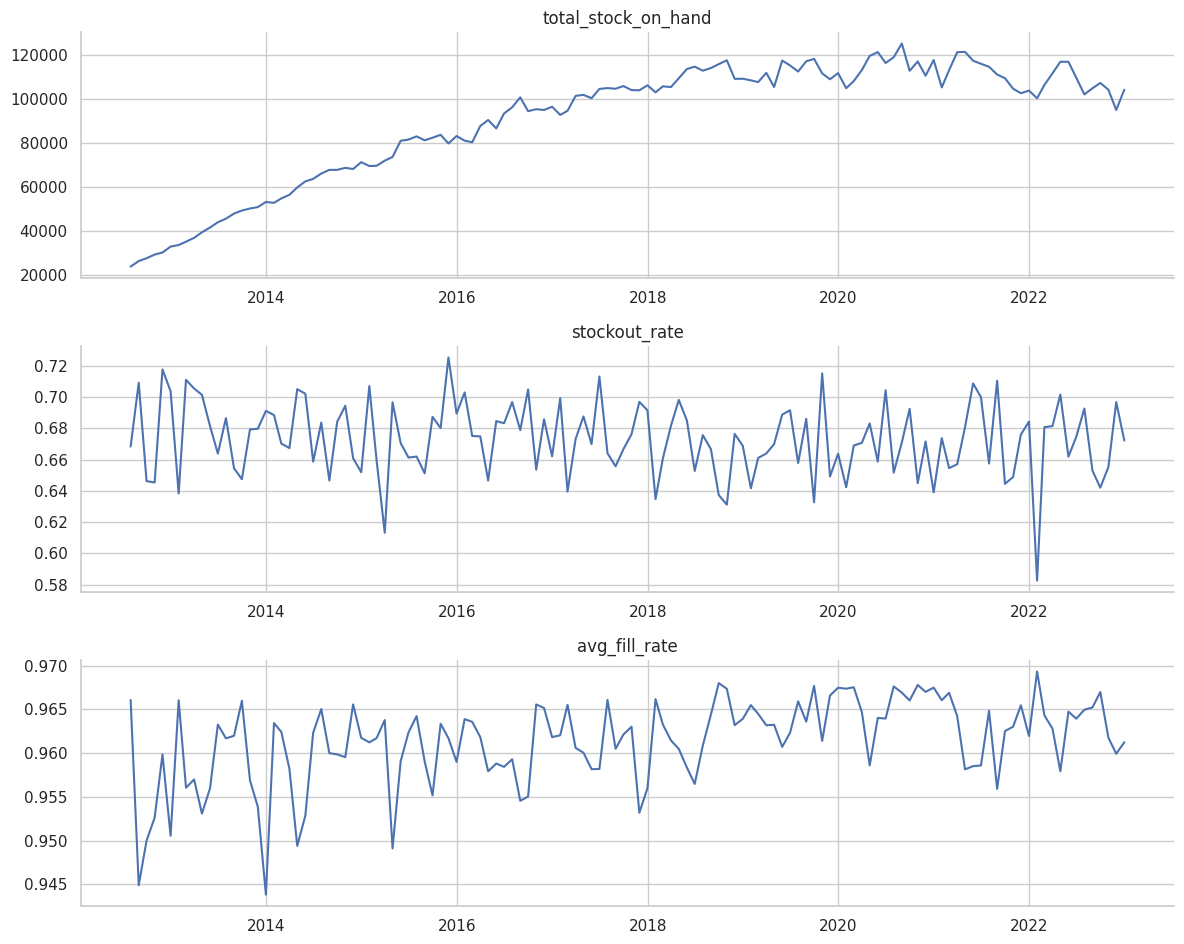

In [121]:
# Vẽ coverage/time series của inventory metrics.
if not inventory_time_summary.empty:
    plot_cols = [c for c in ["total_stock_on_hand", "stockout_rate", "avg_fill_rate"] if c in inventory_time_summary.columns]
    fig, axes = plt.subplots(len(plot_cols), 1, figsize=(12, 3.2 * max(1, len(plot_cols))), squeeze=False)
    for ax, col in zip(axes.flatten(), plot_cols):
        ax.plot(inventory_time_summary["Date"], inventory_time_summary[col], linewidth=1.5)
        ax.set_title(col)
    save_fig("fig_17_inventory_coverage.png")


saved: report_4_6_2026/eda_outputs/figures/fig_18_stockout_vs_revenue.png


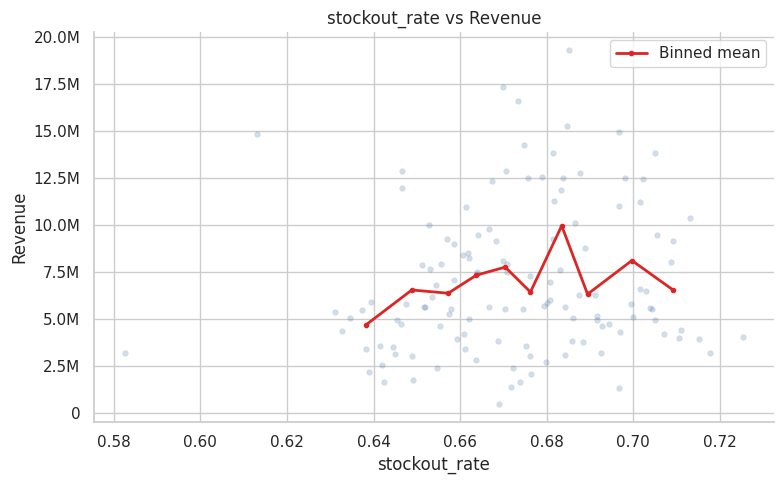

In [122]:
# Vẽ quan hệ inventory feature đại diện với Revenue.
if not inventory_target.empty:
    feature_for_plot = next((c for c in ["stockout_rate", "avg_fill_rate", "total_stock_on_hand"] if c in inventory_target.columns), None)
    if feature_for_plot:
        du.plot_feature_vs_target(inventory_target, feature_for_plot, "Revenue", money_axis=True)
        save_fig("fig_18_stockout_vs_revenue.png")


#### Kết luận chi tiết Giả thuyết H5 (Inventory & Supply Constraints)

**Trạng thái:** `PARTIALLY SUPPORTED (INSIGHT ONLY)` (Hỗ trợ một phần, chỉ dùng làm thông tin bối cảnh).

##### 1. Phân tích Độ phủ (Data Coverage):
- **Tần suất Snapshot:** Dữ liệu tồn kho chỉ có **126 ngày ghi nhận** (snapshots) trên tổng số hơn 3,800 ngày bán hàng (tỷ lệ bao phủ ~3.3%).
- **Hạn chế:** Khoảng cách giữa các lần snapshot quá lớn (thường là theo tháng) khiến dữ liệu này không thể phản ánh các biến động tồn kho hàng ngày hoặc các đợt hết hàng đột xuất (stockouts) trong ngắn hạn.

##### 2. Mối quan hệ với Doanh thu:
- **Tương quan:** Tỷ lệ bán hết (`avg_sell_through_rate`) có tương quan thuận rõ rệt nhất với Revenue (~0.67), cho thấy khi dòng chảy hàng hóa lưu thông tốt, doanh thu sẽ cao.
- **Tồn kho tổng thể:** `total_stock_on_hand` có xu hướng tăng dần theo thời gian (tỷ lệ thuận với quy mô doanh nghiệp) nhưng không giải thích được các biến động trồi sụt (volatility) của doanh thu theo ngày.

##### 3. Đề xuất Feature Engineering:
- **Loại bỏ khỏi Daily Model:** Không đưa các biến inventory vào mô hình dự báo hàng ngày ở Phase đầu tiên vì sẽ tạo ra quá nhiều dữ liệu thiếu (missing values) hoặc gây nhiễu do việc nội suy (interpolation) không chính xác.
- **Sử dụng làm Context:** Có thể dùng để giải thích các giai đoạn doanh thu thấp bất thường trong báo cáo (ví dụ: Revenue giảm do `stockout_rate` tại thời điểm đó cao) thay vì dùng làm tính năng đầu vào trực tiếp cho máy học.

### 6. Tổng hợp giả thuyết, chọn feature candidate và viết Executive Summary

**Mục tiêu**: Tổng hợp kết quả EDA theo H1-H5, đề xuất feature candidate cho bước feature engineering, ghi lại risk register và kết thúc notebook bằng Executive Summary ra quyết định.

#### Quy trình

- 6.1 Hypothesis result summary: chốt kết luận supported/partially supported/not supported cho H1-H5.
- 6.2 Feature candidate catalog: liệt kê candidate có grain, nguồn, transformation và leakage risk.
- 6.3 EDA risk register: ghi rủi ro grain, join, leakage, coverage và target proxy.
- 6.4 Executive Summary: tóm tắt câu chuyện dữ liệu và quyết định bước tiếp theo.

#### 6.1 Hypothesis result summary

**Mục tiêu**: Tổng hợp bằng chứng chính của từng giả thuyết H1-H5 và quyết định giả thuyết đó được dữ liệu ủng hộ ở mức nào.

#### Quy trình

- Ghi kết luận H1-H5: supported, partially supported hoặc not supported.
- Gắn mỗi kết luận với bảng hoặc biểu đồ bằng chứng.
- Diễn giải business meaning của từng kết quả.
- Ghi feature implication nếu giả thuyết nên đi tiếp sang feature engineering.
- Ghi remaining risk nếu dữ liệu chưa đủ mạnh hoặc có rủi ro leakage.

In [123]:
hypothesis_result_summary = pd.DataFrame([
    {"hypothesis_id": "H1", "result": "supported", "key_evidence": "target_descriptive_stats, target_outlier_days, target_monthly_summary, fig_01-fig_04", "business_interpretation": "Target history has clear daily/monthly pattern and outlier/margin issues to manage", "feature_implication": "calendar + shifted target lag/rolling", "remaining_risk": "outlier and negative margin days need review before modeling"},
    {"hypothesis_id": "H2", "result": "partially_supported", "key_evidence": "web_traffic_target_relationship shows medium relation; web traffic coverage starts 2013-01-01", "business_interpretation": "Traffic can proxy online demand but does not cover the full sales period", "feature_implication": "traffic lag/rolling candidate after coverage handling", "remaining_risk": "missing early coverage and same-day leakage depending prediction time"},
    {"hypothesis_id": "H3", "result": "supported_with_leakage_warning", "key_evidence": "orders_target_relationship shows strong relation after daily aggregation", "business_interpretation": "Order volume explains realized revenue very strongly", "feature_implication": "use order lag/rolling only, not same-day order_count for pre-day forecast", "remaining_risk": "same-day order_count is a realized target proxy"},
    {"hypothesis_id": "H4", "result": "partially_supported", "key_evidence": "promotion_target_summary and promotion_calendar_daily", "business_interpretation": "Promo calendar changes revenue/margin profile, but observed promo usage can leak", "feature_implication": "planned promotion calendar features are candidates", "remaining_risk": "promo usage from order_items is realized same-day and should stay insight-only"},
    {"hypothesis_id": "H5", "result": "partially_supported_insight_only", "key_evidence": "inventory_coverage_summary has only 126 snapshot dates; inventory_target_relationship is sparse", "business_interpretation": "Inventory may explain supply constraints but is not daily enough for direct forecast features", "feature_implication": "skip daily inventory feature in first pass; use as context unless alignment strategy is defined", "remaining_risk": "snapshot timing, sparse coverage, and biased daily joins"},
])
save_df(hypothesis_result_summary, "hypothesis_result_summary.csv")
hypothesis_result_summary.to_csv(OUTPUT_DIR / "hypothesis_result_summary.csv", index=False, encoding="utf-8-sig")
du.show(hypothesis_result_summary, title="Hypothesis result summary")


saved: report_4_6_2026/eda_outputs/tables/hypothesis_result_summary.csv

Hypothesis result summary


,hypothesis_id,result,key_evidence,business_interpretation,feature_implication,remaining_risk
0,H1,supported,"target_descriptive_stats, target_outlier_days,...",Target history has clear daily/monthly pattern...,calendar + shifted target lag/rolling,outlier and negative margin days need review b...
1,H2,partially_supported,web_traffic_target_relationship shows medium r...,Traffic can proxy online demand but does not c...,traffic lag/rolling candidate after coverage h...,missing early coverage and same-day leakage de...
2,H3,supported_with_leakage_warning,orders_target_relationship shows strong relati...,Order volume explains realized revenue very st...,"use order lag/rolling only, not same-day order...",same-day order_count is a realized target proxy
3,H4,partially_supported,promotion_target_summary and promotion_calenda...,"Promo calendar changes revenue/margin profile,...",planned promotion calendar features are candid...,promo usage from order_items is realized same-...
4,H5,partially_supported_insight_only,inventory_coverage_summary has only 126 snapsh...,Inventory may explain supply constraints but i...,skip daily inventory feature in first pass; us...,"snapshot timing, sparse coverage, and biased d..."


#### 6.2 Feature candidate catalog

**Mục tiêu**: Đề xuất feature candidate cho bước feature engineering nhưng chưa chốt feature cuối cùng trong EDA.

#### Quy trình

- Liệt kê feature từ target history, calendar, traffic, orders, promotions và inventory.
- Ghi source table và original grain của từng feature candidate.
- Ghi modeling grain cần đưa về, thường là daily.
- Ghi suggested transformation như lag, rolling, count, rate hoặc calendar flag.
- Ghi leakage risk và decision for next step.

In [124]:
eda_feature_candidate_catalog = pd.DataFrame([
    {"feature_candidate": "Revenue_lag_1d/7d/rolling_7d/30d", "source_table": "sales", "original_grain": "daily", "modeling_grain": "daily", "suggested_transformation": "shift before rolling", "expected_relation_to_target": "strong baseline signal", "leakage_risk": "low if shifted", "business_reason": "sales has temporal persistence", "decision_for_next_step": "candidate"},
    {"feature_candidate": "COGS_lag_1d/7d/rolling_7d/30d", "source_table": "sales", "original_grain": "daily", "modeling_grain": "daily", "suggested_transformation": "shift before rolling", "expected_relation_to_target": "strong baseline signal", "leakage_risk": "low if shifted", "business_reason": "cost moves with sales volume/product mix", "decision_for_next_step": "candidate"},
    {"feature_candidate": "calendar_day_of_week/month/year", "source_table": "Date", "original_grain": "daily", "modeling_grain": "daily", "suggested_transformation": "derive from Date", "expected_relation_to_target": "seasonality", "leakage_risk": "low", "business_reason": "shopping behavior changes by calendar", "decision_for_next_step": "candidate"},
    {"feature_candidate": "traffic_lag/rolling", "source_table": "web_traffic", "original_grain": "daily or date x source", "modeling_grain": "daily", "suggested_transformation": "aggregate daily then lag/rolling", "expected_relation_to_target": "demand signal", "leakage_risk": "medium same-day, lower if lag", "business_reason": "traffic precedes orders", "decision_for_next_step": "candidate_if_relation"},
    {"feature_candidate": "order_count_lag/rolling", "source_table": "orders", "original_grain": "order", "modeling_grain": "daily", "suggested_transformation": "aggregate daily then lag/rolling", "expected_relation_to_target": "volume signal", "leakage_risk": "high same-day, lower if lag", "business_reason": "orders realize demand", "decision_for_next_step": "candidate_only_lagged"},
    {"feature_candidate": "active_promo_count/avg_active_discount", "source_table": "promotions", "original_grain": "promotion", "modeling_grain": "daily", "suggested_transformation": "calendar expansion by active date", "expected_relation_to_target": "promotion effect", "leakage_risk": "low if campaign calendar known", "business_reason": "planned discount changes demand/margin", "decision_for_next_step": "candidate"},
    {"feature_candidate": "inventory_stockout_rate/fill_rate", "source_table": "inventory", "original_grain": "snapshot", "modeling_grain": "snapshot/monthly context", "suggested_transformation": "aggregate only at valid snapshot grain", "expected_relation_to_target": "supply constraint insight", "leakage_risk": "medium depends snapshot timing", "business_reason": "stockout can cap sales but coverage is not daily", "decision_for_next_step": "skip_first_pass_insight_only"},
])
save_df(eda_feature_candidate_catalog, "eda_feature_candidate_catalog.csv")
eda_feature_candidate_catalog.to_csv(OUTPUT_DIR / "eda_feature_candidate_catalog.csv", index=False, encoding="utf-8-sig")
du.show(eda_feature_candidate_catalog, title="Feature candidate catalog")


saved: report_4_6_2026/eda_outputs/tables/eda_feature_candidate_catalog.csv

Feature candidate catalog


,feature_candidate,source_table,original_grain,modeling_grain,suggested_transformation,expected_relation_to_target,leakage_risk,business_reason,decision_for_next_step
0,Revenue_lag_1d/7d/rolling_7d/30d,sales,daily,daily,shift before rolling,strong baseline signal,low if shifted,sales has temporal persistence,candidate
1,COGS_lag_1d/7d/rolling_7d/30d,sales,daily,daily,shift before rolling,strong baseline signal,low if shifted,cost moves with sales volume/product mix,candidate
2,calendar_day_of_week/month/year,Date,daily,daily,derive from Date,seasonality,low,shopping behavior changes by calendar,candidate
3,traffic_lag/rolling,web_traffic,daily or date x source,daily,aggregate daily then lag/rolling,demand signal,"medium same-day, lower if lag",traffic precedes orders,candidate_if_relation
4,order_count_lag/rolling,orders,order,daily,aggregate daily then lag/rolling,volume signal,"high same-day, lower if lag",orders realize demand,candidate_only_lagged
5,active_promo_count/avg_active_discount,promotions,promotion,daily,calendar expansion by active date,promotion effect,low if campaign calendar known,planned discount changes demand/margin,candidate
6,inventory_stockout_rate/fill_rate,inventory,snapshot,snapshot/monthly context,aggregate only at valid snapshot grain,supply constraint insight,medium depends snapshot timing,stockout can cap sales but coverage is not daily,skip_first_pass_insight_only


#### 6.3 EDA risk register

**Mục tiêu**: Ghi lại các rủi ro có thể làm sai phân tích hoặc làm model bị leakage trước khi chuyển sang feature engineering.

#### Quy trình

- Ghi rủi ro grain mismatch giữa bảng nguồn và target daily.
- Ghi rủi ro join làm nhân dòng hoặc sai doanh thu.
- Ghi rủi ro same-day feature dùng thông tin không biết trước tại thời điểm forecast.
- Ghi rủi ro coverage không đủ theo thời gian.
- Ghi mitigation cho từng rủi ro để bước sau kiểm tra lại.

In [125]:
eda_risk_register = pd.DataFrame([
    {"risk_area": "grain", "description": "Raw order/order_items data is not daily grain", "affected_tables": "orders, order_items", "impact_on_analysis_or_model": "join raw to sales can multiply rows", "mitigation": "aggregate to daily before joining sales"},
    {"risk_area": "leakage", "description": "Same-day realized order_count/promo usage may not be known before forecast day", "affected_tables": "orders, order_items", "impact_on_analysis_or_model": "validation score can be unrealistically good", "mitigation": "use lag/rolling or planned calendar only"},
    {"risk_area": "coverage", "description": "Traffic/inventory may not cover full target period", "affected_tables": "web_traffic, inventory", "impact_on_analysis_or_model": "missing feature period or biased relation", "mitigation": "report coverage and skip/fill only with reason"},
    {"risk_area": "target proxy", "description": "Item-level revenue/COGS can duplicate target information", "affected_tables": "order_items, products", "impact_on_analysis_or_model": "model learns target proxy rather than forecast signal", "mitigation": "keep product mix as insight, do not use same-day net revenue as feature"},
])
save_df(eda_risk_register, "eda_risk_register.csv")
eda_risk_register.to_csv(OUTPUT_DIR / "eda_risk_register.csv", index=False, encoding="utf-8-sig")
du.show(eda_risk_register, title="EDA risk register")


saved: report_4_6_2026/eda_outputs/tables/eda_risk_register.csv

EDA risk register


,risk_area,description,affected_tables,impact_on_analysis_or_model,mitigation
0,grain,Raw order/order_items data is not daily grain,"orders, order_items",join raw to sales can multiply rows,aggregate to daily before joining sales
1,leakage,Same-day realized order_count/promo usage may ...,"orders, order_items",validation score can be unrealistically good,use lag/rolling or planned calendar only
2,coverage,Traffic/inventory may not cover full target pe...,"web_traffic, inventory",missing feature period or biased relation,report coverage and skip/fill only with reason
3,target proxy,Item-level revenue/COGS can duplicate target i...,"order_items, products",model learns target proxy rather than forecast...,"keep product mix as insight, do not use same-d..."


#### 6.4 Executive Summary

**Mục tiêu**: Kết thúc notebook bằng bản tóm tắt ra quyết định: dữ liệu đang nói gì, bảng nào dùng được, bảng nào rủi ro và bước sau nên làm gì.

#### Quy trình

- Tóm tắt câu chuyện chính quanh daily Revenue/COGS.
- Tóm tắt kết quả theo H1-H5.
- Tóm tắt driver có vẻ quan trọng nhất.
- Tóm tắt feature candidate nên đưa sang feature engineering.
- Ghi open questions trước modeling.

In [126]:
summary_md = f'''
# EDA Summary - report_4_6_2026

## Câu chuyện chính

Dữ liệu cho thấy daily `Revenue` và `COGS` có tín hiệu thời gian rõ, order volume là driver mạnh nhất của realized revenue, web traffic và promotion có giá trị giải thích/feature candidate có điều kiện, còn inventory chỉ nên dùng như context vì coverage snapshot quá thưa cho daily forecast.

## Scope đã xác nhận

- Target: `Revenue`, `COGS` từ `sales`.
- Forecast grain: 1 dòng = 1 ngày từ `sample_submission`.
- Train period: {sales['Date'].min().date()} đến {sales['Date'].max().date()}.
- Forecast period: {sample_submission['Date'].min().date()} đến {sample_submission['Date'].max().date()}.
- EDA chính kiểm chứng H1-H5, chưa clean mạnh, chưa chốt feature cuối cùng, chưa train model.

## Kết luận H1-H5

- H1 `supported`: target history có trend/seasonality/outlier và đáng chuyển sang calendar + lag/rolling feature.
- H2 `partially_supported`: traffic có quan hệ mức trung bình với target, nhưng thiếu coverage đầu kỳ và same-day có thể leak.
- H3 `supported_with_leakage_warning`: order volume quan hệ rất mạnh với Revenue/COGS, nhưng same-day order_count không an toàn cho forecast trước ngày.
- H4 `partially_supported`: promotion calendar có giá trị, promo usage trong order_items chỉ nên dùng insight vì realized same-day.
- H5 `partially_supported_insight_only`: inventory có tín hiệu constraint nhưng chỉ có snapshot thưa, không đủ daily coverage để dùng feature bản đầu.

## Output chính

- `eda_outputs/tables/target_selection_check.csv`
- `eda_outputs/tables/forecast_scope_check.csv`
- `eda_outputs/tables/a_scope_answer_check.csv`
- `eda_outputs/tables/hypothesis_backlog.csv`
- `eda_outputs/tables/hypothesis_feasibility_check.csv`
- `eda_outputs/tables/hypothesis_result_summary.csv`
- `eda_outputs/tables/eda_feature_candidate_catalog.csv`
- `eda_outputs/tables/eda_risk_register.csv`
- `eda_outputs/figures/fig_01_daily_revenue_cogs.png` đến `fig_18_stockout_vs_revenue.png` theo danh sách trong plan.

## Rủi ro trước feature engineering/modeling

- Không join raw `orders`/`order_items` vào `sales` daily vì sẽ nhân dòng.
- Không dùng same-day `order_count` hoặc promo usage realized làm feature forecast trước ngày.
- Cần xử lý coverage thiếu của `web_traffic` trước khi đưa vào model.
- Không ép `inventory` snapshot thưa thành daily feature nếu chưa có chiến lược alignment hợp lý.
'''

summary_path = REPORT_DIR / "EDA_summary.md"
summary_path.write_text(summary_md, encoding="utf-8")
print(f"saved: {summary_path.relative_to(PROJECT_ROOT)}")


saved: report_4_6_2026/EDA_summary.md
